# 2.Exploratory Data Analysis (EDA)
 ---

**Assignment:** *Machine Learning 2026 — NOVA School of Business and Economics*  
**Dataset:** Predict students' dropout and academic success  
**Goal:** Identify high-risk students at the end of their first semester using: Socio-economic background, Enrollment data and 1st semester academic performance


 

    71907 Lavinia Antonino | 71993 Mª Teresa Silva | 73171 Leonardo Cantu | 72731 Edoardo Sirianni | 71947 Carolina Diogo
 ---

## Table of contents

1. [Introduction](#1-introduction)
2. [Target Variable Analysis](#2-target-variable-analysis)
3. [Univariate Analysis](#3-univariate-analysis)
   - 3.1 [Demographic & Personal Background](#31-demographic--personal-background)
   - 3.2 [Socioeconomic & Family Background](#32-socioeconomic--family-background)
   - 3.3 [Enrollment & Application Profile](#33-enrollment--application-profile)
   - 3.4 [Financial Status](#34-financial-status)
   - 3.5 [1st Semester Academic Performance](#35-1st-semester-academic-performance)
   - 3.6 [Macroeconomic Context](#36-macroeconomic-context)
4. [Bivariate Analysis — Each Group vs Target](#4-bivariate-analysis--each-group-vs-target)
   - 4.1 [Demographic & Personal Background vs Target](#41-demographic--personal-background-vs-target)
   - 4.2 [Socioeconomic & Family Background vs Target](#42-socioeconomic--family-background-vs-target)
   - 4.3 [Enrollment & Application Profile vs Target](#43-enrollment--application-profile-vs-target)
   - 4.4 [Financial Status vs Target](#44-financial-status-vs-target)
   - 4.5 [1st Semester Academic Performance vs Target](#45-1st-semester-academic-performance-vs-target)
   - 4.6 [Macroeconomic Context vs Target](#46-macroeconomic-context-vs-target)
5. [Multivariate Analysis](#5-multivariate-analysis)
   - 5.1 [Multicollinearity & Redundancy](#51-multicollinearity--redundancy)
   - 5.2 [Key Interactions vs Target](#52-key-interactions-vs-target)
6. [Key Findings & Takeaways](#6-key-findings--takeaways)



---

## 1. Introduction

This notebook presents the Exploratory Data Analysis (EDA) for the student dropout prediction project. The analysis is structured in four progressive stages. We begin by examining the target variable distribution to assess class balance before moving into univariate analysis, where each variable is studied independently across six thematic groups: demographic and personal background, 
socioeconomic and family background, enrollment and application profile, financial status, 1st semester academic performance, and macroeconomic context. Each group is assessed for distributional shape, skewness, zero-inflation, and low-variance issues that would require transformation or removal before modelling.

The second half of the notebook shifts from individual variables to relationships. The bivariate analysis examines how each variable relates to the dropout target, following the same six-group structure to maintain consistency. This is followed by a multivariate analysis that checks for 
multicollinearity and redundancy across variable groups, and tests two priority interactions against the target to validate the variable selection decisions made in earlier sections. The notebook closes with a consolidated summary of key findings, covering which variables to keep, transform, or drop, and flagging the main feature engineering candidates to be addressed in the 
next phase.

In [157]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Optional
from pathlib import Path
from scipy.stats import chi2_contingency
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('husl')

pd.set_option('display.max_columns', None)

---

## 1. Data Loading

In [158]:
print(Path.cwd())

df = pd.read_csv('../datasets/df_model.csv')

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()

c:\Users\mtere\Desktop\Machine-Learning-Group-Project\notebooks
Shape   : (3618, 30)
Columns : ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'Target_binary']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_binary
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
1,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,1
2,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,9.4,-0.8,-3.12,Graduate,0
3,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,13.9,-0.3,0.79,Graduate,0
4,2,12,1,17,0,12,1,22,27,10,8,0,0,1,1,1,0,50,0,0,5,10,5,11.857143,0,16.2,0.3,-0.92,Graduate,0


In [159]:
# Load variable groups
with open('variable_groups.json') as f:
    variable_groups = json.load(f)

demographic      = variable_groups['Demographic & Personal Background']
socioeconomic    = variable_groups['Socioeconomic & Family Background']
enrollment       = variable_groups['Enrollment & Application Profile']
financial        = variable_groups['Financial Status']
academic_1st_sem = variable_groups['1st Semester Academic Performance']
macroeconomic    = variable_groups['Macroeconomic Context']

---

## 2. Target Variable Analysis

Before any analysis, it is important to understand the distribution of the target variable. 
Since the goal is to predict dropout risk, the target was recoded into a binary variable -
**Dropout (1) vs. Non-Dropout (0)** - combining Graduate and Enrolled students into a single class.

A class imbalance check is critical at this stage, as an imbalanced target can bias the model 
towards the majority class, leading to poor identification of at-risk students, which is precisely 
the outcome we want to avoid.

             Count Percentage
Non-Dropout   2201     60.83%
Dropout       1417     39.17%


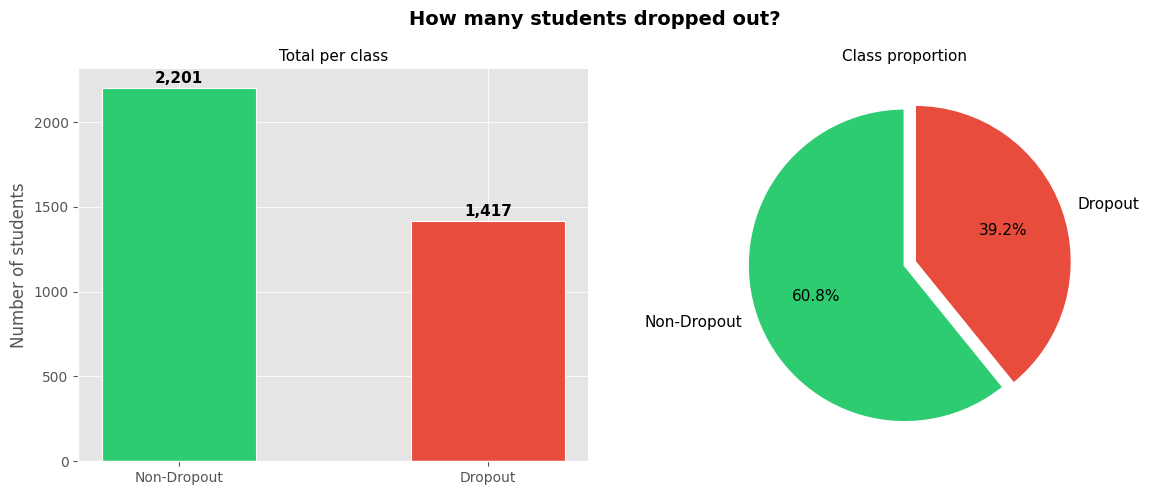


Imbalance ratio: 1.55


In [160]:
# Target variable distribution

target_counts = df['Target_binary'].value_counts()
target_props  = df['Target_binary'].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    'Count'      : target_counts,
    'Percentage' : target_props.astype(str) + '%'
})
target_summary.index = ['Non-Dropout', 'Dropout']
print(target_summary)

 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('How many students dropped out?', fontsize=14, fontweight='bold')

# Bar plot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(
    ['Non-Dropout', 'Dropout'],
    target_counts,
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)
axes[0].set_title('Total per class', fontsize=11)
axes[0].set_ylabel('Number of students')
axes[0].spines[['top', 'right']].set_visible(False)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=11, fontweight='bold'
    )

# Pie chart
axes[1].pie(
    target_counts,
    labels=['Non-Dropout', 'Dropout'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.07),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11}
)
axes[1].set_title('Class proportion', fontsize=11)

plt.tight_layout()
plt.show()

# Imbalance ratio
ratio = target_counts.max() / target_counts.min()
print(f"\nImbalance ratio: {ratio:.2f}")

The modelling set contains 3,618 students: 2,201 Non-Dropouts (60.8%) and 1,417 Dropouts (39.2%), with an imbalance ratio of 1.55.

At 1.55, the class imbalance is mild and unlikely to require aggressive resampling techniques such as SMOTE. Stratified cross-validation should be used throughout modelling, and evaluation should prioritise F1-score and AUC-ROC over accuracy to ensure the Dropout class is adequately captured.

---

## 3. Univariate Analysis

Before looking at how variables relate to dropout, it is important to understand each variable on its own. Its distribution, range, and whether anything looks unusual. This section goes through all variables organized by the 6 thematic groups defined in the cleaning stage.

Three helper functions were defined to handle the univariate analysis of each variable type. `plot_binary()` produces a bar chart and a pie chart, showing both the absolute count and the relative proportion of each class. `plot_categorical()` produces two horizontal bar charts side by side — one with absolute frequencies and one with relative frequencies, making it easy to compare categories regardless of their size. `plot_continuous()` prints a descriptive statistics table and produces a histogram alongside a boxplot, allowing a quick read of the distribution shape, central tendency, spread, and potential outliers. All functions follow the same structure and colour scheme for consistency across the analysis.


In [161]:
# Variable type registry 

BINARY_VARS = [
    'Displaced', 'International', 'Gender',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder',
    'Daytime/evening attendance', 'Educational special needs'
]

CATEGORICAL_VARS = [
    'Marital status', 'Nacionality', 'Application mode', 'Application order',
    'Course', 'Previous qualification',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

CONTINUOUS_VARS = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]


# Type resolver 

def _get_var_type(col: str, series: pd.Series) -> str:
    """Resolve variable type: binary, categorical, or continuous."""
    if col in BINARY_VARS or set(series.dropna().unique()) <= {0, 1}:
        return "binary"
    if col in CATEGORICAL_VARS:
        return "categorical"
    if col in CONTINUOUS_VARS:
        return "continuous"
    # fallback: infer from unique count
    n_unique = series.nunique()
    if n_unique <= 20:
        return "categorical"
    return "continuous"


#  Palette & style

PALETTE = {
    "no":   "#4C72B0",
    "yes":  "#DD8452",
    "cat":  "#55A868",
    "cont": "#C44E52",
    "grid": "#E8E8E8",
    "text": "#2D2D2D",
}

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        PALETTE["grid"],
    "grid.linewidth":    0.6,
    "axes.labelcolor":   PALETTE["text"],
    "xtick.color":       PALETTE["text"],
    "ytick.color":       PALETTE["text"],
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})


# Validation 

def _validate(df: pd.DataFrame, col: str) -> Optional[str]:
    if col not in df.columns:
        return f"Column '{col}' not found. Available: {list(df.columns)}"
    if df[col].isna().all():
        return f"Column '{col}' contains only NaN values."
    return None

def _warn(msg: str) -> None:
    print(f"[plot warning] {msg}")


# Plot renderers (used internally by plot_group) 

def _render_binary(ax_l, ax_r, series, col):
    counts = series.value_counts().reindex([0, 1], fill_value=0)
    labels = ["No (0)", "Yes (1)"]
    colors = [PALETTE["no"], PALETTE["yes"]]

    bars = ax_l.bar(labels, counts, color=colors,
                    edgecolor="white", linewidth=1.5, width=0.45, zorder=3)
    ax_l.set_title(f"{col}  ·  Absolute Frequency", fontsize=9, pad=6)
    ax_l.set_ylabel("Count")
    ax_l.grid(axis="x", visible=False)
    ax_l.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar in bars:
        h = bar.get_height()
        ax_l.text(bar.get_x() + bar.get_width() / 2,
                  h + counts.max() * 0.02, f"{int(h):,}",
                  ha="center", va="bottom", fontsize=9,
                  fontweight="bold", color=PALETTE["text"])

    _, _, autotexts = ax_r.pie(
        counts, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=90, explode=(0, 0.05),
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 9, "color": PALETTE["text"]},
    )
    for at in autotexts:
        at.set_fontweight("bold")
    ax_r.set_title(f"{col}  ·  Relative Frequency", fontsize=9, pad=6)


def _render_categorical(ax_l, ax_r, series, col, max_categories=10):
    counts = series.value_counts().sort_values(ascending=True)
    if len(counts) > max_categories:
        counts = counts.tail(max_categories)
    relative = counts / counts.sum() * 100
    color    = PALETTE["cat"]

    def _hbar(ax, values, xlabel, fmt, title):
        bars = ax.barh(values.index.astype(str), values.values,
                       color=color, edgecolor="white",
                       linewidth=1.2, zorder=3, height=0.65)
        ax.set_title(title, fontsize=9, pad=6)
        ax.set_xlabel(xlabel)
        ax.grid(axis="y", visible=False)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
        for bar in bars:
            w = bar.get_width()
            ax.text(w + values.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    fmt(w), va="center", fontsize=7, color=PALETTE["text"])

    _hbar(ax_l, counts,   "Count",          lambda x: f"{int(x):,}",
          f"{col}  ·  Absolute Frequency")
    _hbar(ax_r, relative, "Percentage (%)", lambda x: f"{x:.1f}%",
          f"{col}  ·  Relative Frequency (%)")


def _render_continuous(ax_l, ax_r, series, col):
    color = PALETTE["cont"]

    ax_l.hist(series, bins=30, color=color, edgecolor="white",
              linewidth=0.5, zorder=3)
    ax_l.axvline(series.mean(),   color="#333", lw=1.4, ls="--",
                 label=f"Mean   {series.mean():.2f}")
    ax_l.axvline(series.median(), color="#888", lw=1.4, ls=":",
                 label=f"Median {series.median():.2f}")
    ax_l.set_title(f"{col}  ·  Distribution", fontsize=9, pad=6)
    ax_l.set_xlabel(col)
    ax_l.set_ylabel("Count")
    ax_l.legend(fontsize=7, framealpha=0.6)
    ax_l.grid(axis="x", visible=False)

    ax_r.boxplot(
        series, patch_artist=True, vert=False,
        boxprops    =dict(facecolor=color, color="white",  linewidth=1.5),
        medianprops =dict(color="white",   linewidth=2.5),
        whiskerprops=dict(color="#888",    linewidth=1.2),
        capprops    =dict(color="#888",    linewidth=1.2),
        flierprops  =dict(marker="o",      color="#888",
                          alpha=0.35,      markersize=3),
    )
    ax_r.set_title(f"{col}  ·  Boxplot", fontsize=9, pad=6)
    ax_r.set_xlabel(col)
    ax_r.set_yticks([])
    ax_r.grid(axis="y", visible=False)
    ax_r.text(
        0.98, 0.95,
        "\n".join([
            f"Mean   {series.mean():.4g}",
            f"Median {series.median():.4g}",
            f"Std    {series.std():.4g}",
            f"IQR    {series.quantile(.75) - series.quantile(.25):.4g}",
            f"Min    {series.min():.4g}",
            f"Max    {series.max():.4g}",
        ]),
        transform=ax_r.transAxes,
        fontsize=7, va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor=PALETTE["grid"], alpha=0.85),
    )


# User-facing functions 

def plot_binary(df: pd.DataFrame, col: str, group_name: str = "") -> None:
    if err := _validate(df, col):
        return _warn(err)
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{col}" + (f"  ·  {group_name}" if group_name else ""),
                 fontsize=13, fontweight="bold", color=PALETTE["text"], y=1.02)
    _render_binary(ax_l, ax_r, df[col].dropna(), col)
    fig.tight_layout()
    plt.show()


def plot_categorical(df: pd.DataFrame, col: str, group_name: str = "",
                     max_categories: int = 30) -> None:
    if err := _validate(df, col):
        return _warn(err)
    series = df[col].dropna()
    height = max(4, min(series.nunique(), max_categories) * 0.45)
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, height))
    fig.suptitle(f"{col}" + (f"  ·  {group_name}" if group_name else ""),
                 fontsize=13, fontweight="bold", color=PALETTE["text"], y=1.02)
    _render_categorical(ax_l, ax_r, series, col, max_categories)
    fig.tight_layout()
    plt.show()


def plot_continuous(df: pd.DataFrame, col: str, group_name: str = "",
                    bins: int = 30) -> None:
    if err := _validate(df, col):
        return _warn(err)
    series = df[col].dropna()
    stats  = series.describe()
    print(f"\n  {col}  —  Descriptive Statistics")
    print(f"  {'n':>10}: {int(stats['count']):,}")
    for k in ("mean", "std", "min", "25%", "50%", "75%", "max"):
        print(f"  {k:>10}: {stats[k]:.4g}")
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{col}" + (f"  ·  {group_name}" if group_name else ""),
                 fontsize=13, fontweight="bold", color=PALETTE["text"], y=1.02)
    _render_continuous(ax_l, ax_r, series, col)
    fig.tight_layout()
    plt.show()


def plot_group(df, variables, group_name="", max_categories=10):
    if err := _validate(df, "Target"):
        return _warn(err)

    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 2, figsize=(14, n_vars * 4))
    fig.suptitle(f"{group_name}  ·  Individual Analysis",
                 fontsize=15, fontweight="bold", color=PALETTE["text"], y=1.01)

    if n_vars == 1:
        axes = [axes]

    for row, col in enumerate(variables):
        if err := _validate(df, col):
            _warn(err)
            continue

        series   = df[col].dropna()
        var_type = _get_var_type(col, series)
        ax_l     = axes[row][0]
        ax_r     = axes[row][1]

        if var_type == "binary":
            _render_binary(ax_l, ax_r, series, col)
        elif var_type == "categorical":
            _render_categorical(ax_l, ax_r, series, col, max_categories)
        else:
            _render_continuous(ax_l, ax_r, series, col)

    fig.tight_layout()
    plt.show()

### 3.1 Demographic & Personal Background

This group covers the personal characteristics of each student at the time of enrollment. It includes marital status and nationality as categorical variables, gender, international status, and displaced status as binary variables, and age at enrollment as the only continuous variable in this group. Together, these variables provide a baseline portrait of who the student is before any academic or financial context is considered.

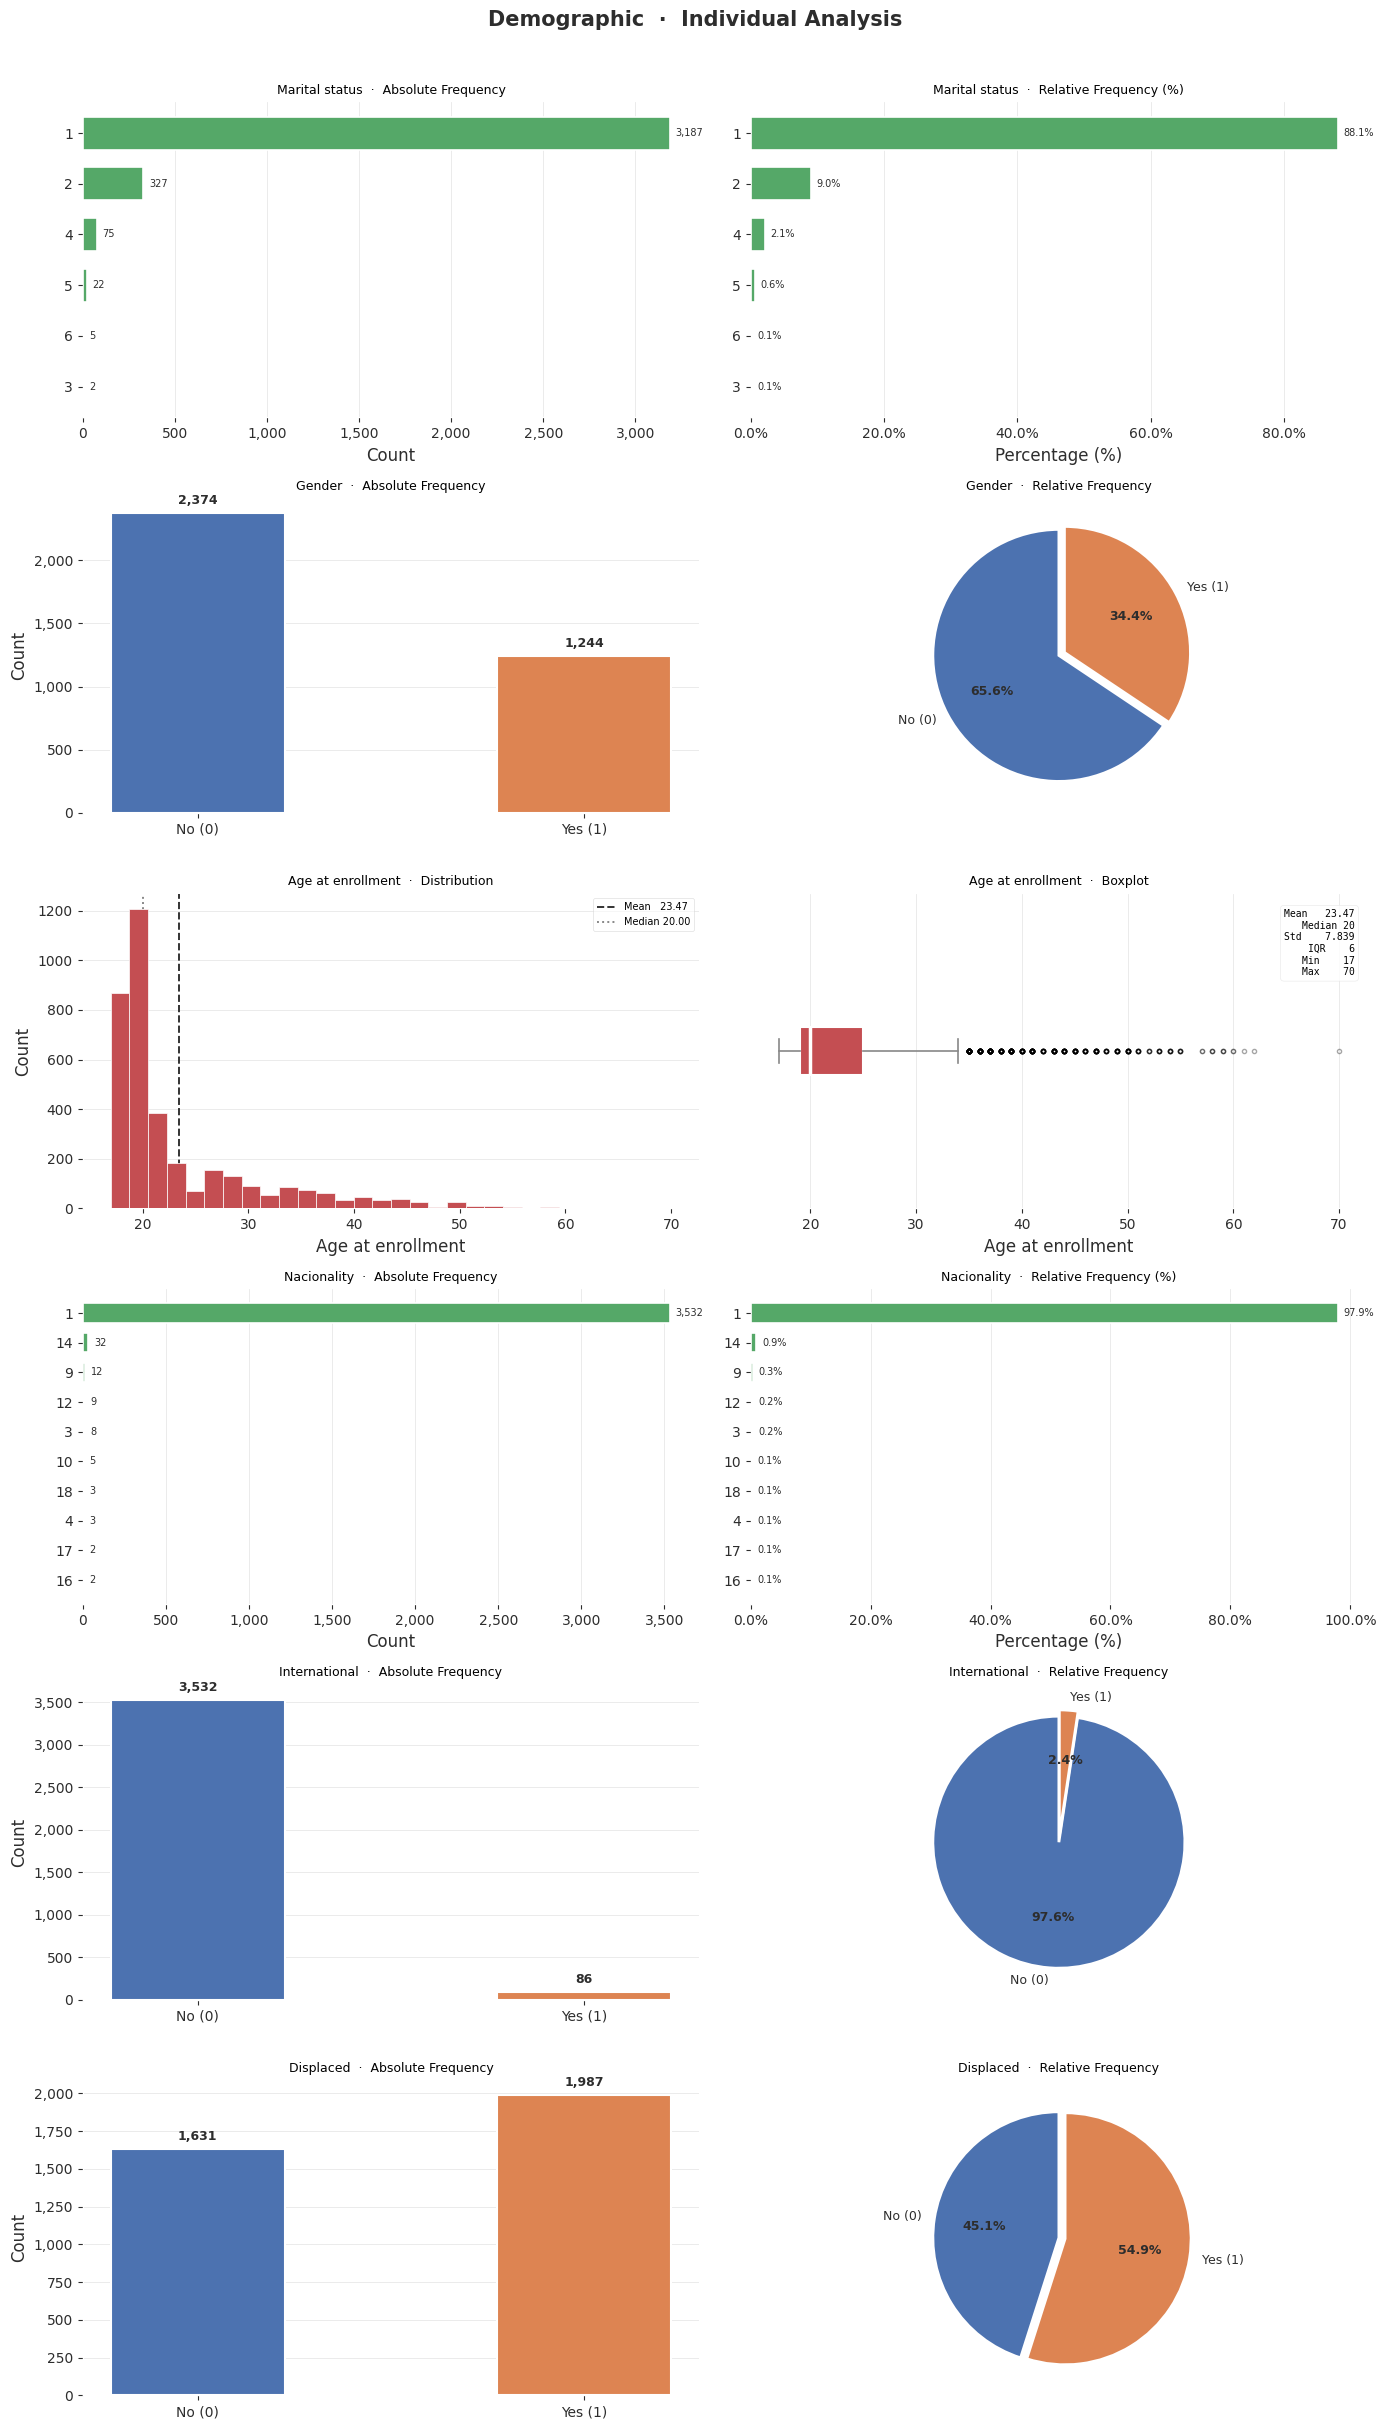

In [162]:
plot_group(df, demographic,      group_name="Demographic")

***Descriptive Analysis***

**Marital status** — Single students (code 1) dominate at 88.1%, with Married (code 2) at 9.0% and all other categories below 2.1%. The distribution is near-constant and sparse outside code 1.

**Gender** — 65.6% female (code 0) and 34.4% male (code 1). The split is uneven but consistent with the full dataset distribution prior to excluding Enrolled students.

**Age at enrollment** — Right-skewed with median 20 and mean 23.47. The bulk of students enroll between 17–25, with a long tail extending to 70. IQR of 6 confirms a tight central cluster despite the wide range.

**Nationality** — Near-constant at 97.9% Portuguese (code 1). All other nationalities individually represent 0.1–0.9% of the modelling set.

**International** — 97.6% domestic students. Only 86 international students remain in the modelling set after excluding Enrolled — too few for reliable inference.

**Displaced** — Relatively balanced at 45.1% non-displaced vs 54.9% displaced, unchanged from the full dataset.

***Key Insights***

Nationality and International are near-constant and carry negligible predictive signal: both are strong candidates for removal. Marital status is similarly dominated by a single category and will require consolidation before modelling. Gender (65/35 split) and Displaced (45/55 split) are the most balanced variables in the group and are ready to use as-is. Age at enrollment is right-skewed with a long tail of mature students, SO binning or a log transform is recommended before modelling.

### 3.2 Socioeconomic & Family Background

This group captures the family context surrounding each student. Parental qualifications and occupations are represented as categorical variables, reflecting the educational and professional level of the student's household. Educational special needs is included as a binary variable. Together, these variables help assess whether a student's family background plays a role in their risk of dropping out, a relationship that is well documented in the literature on academic persistence.

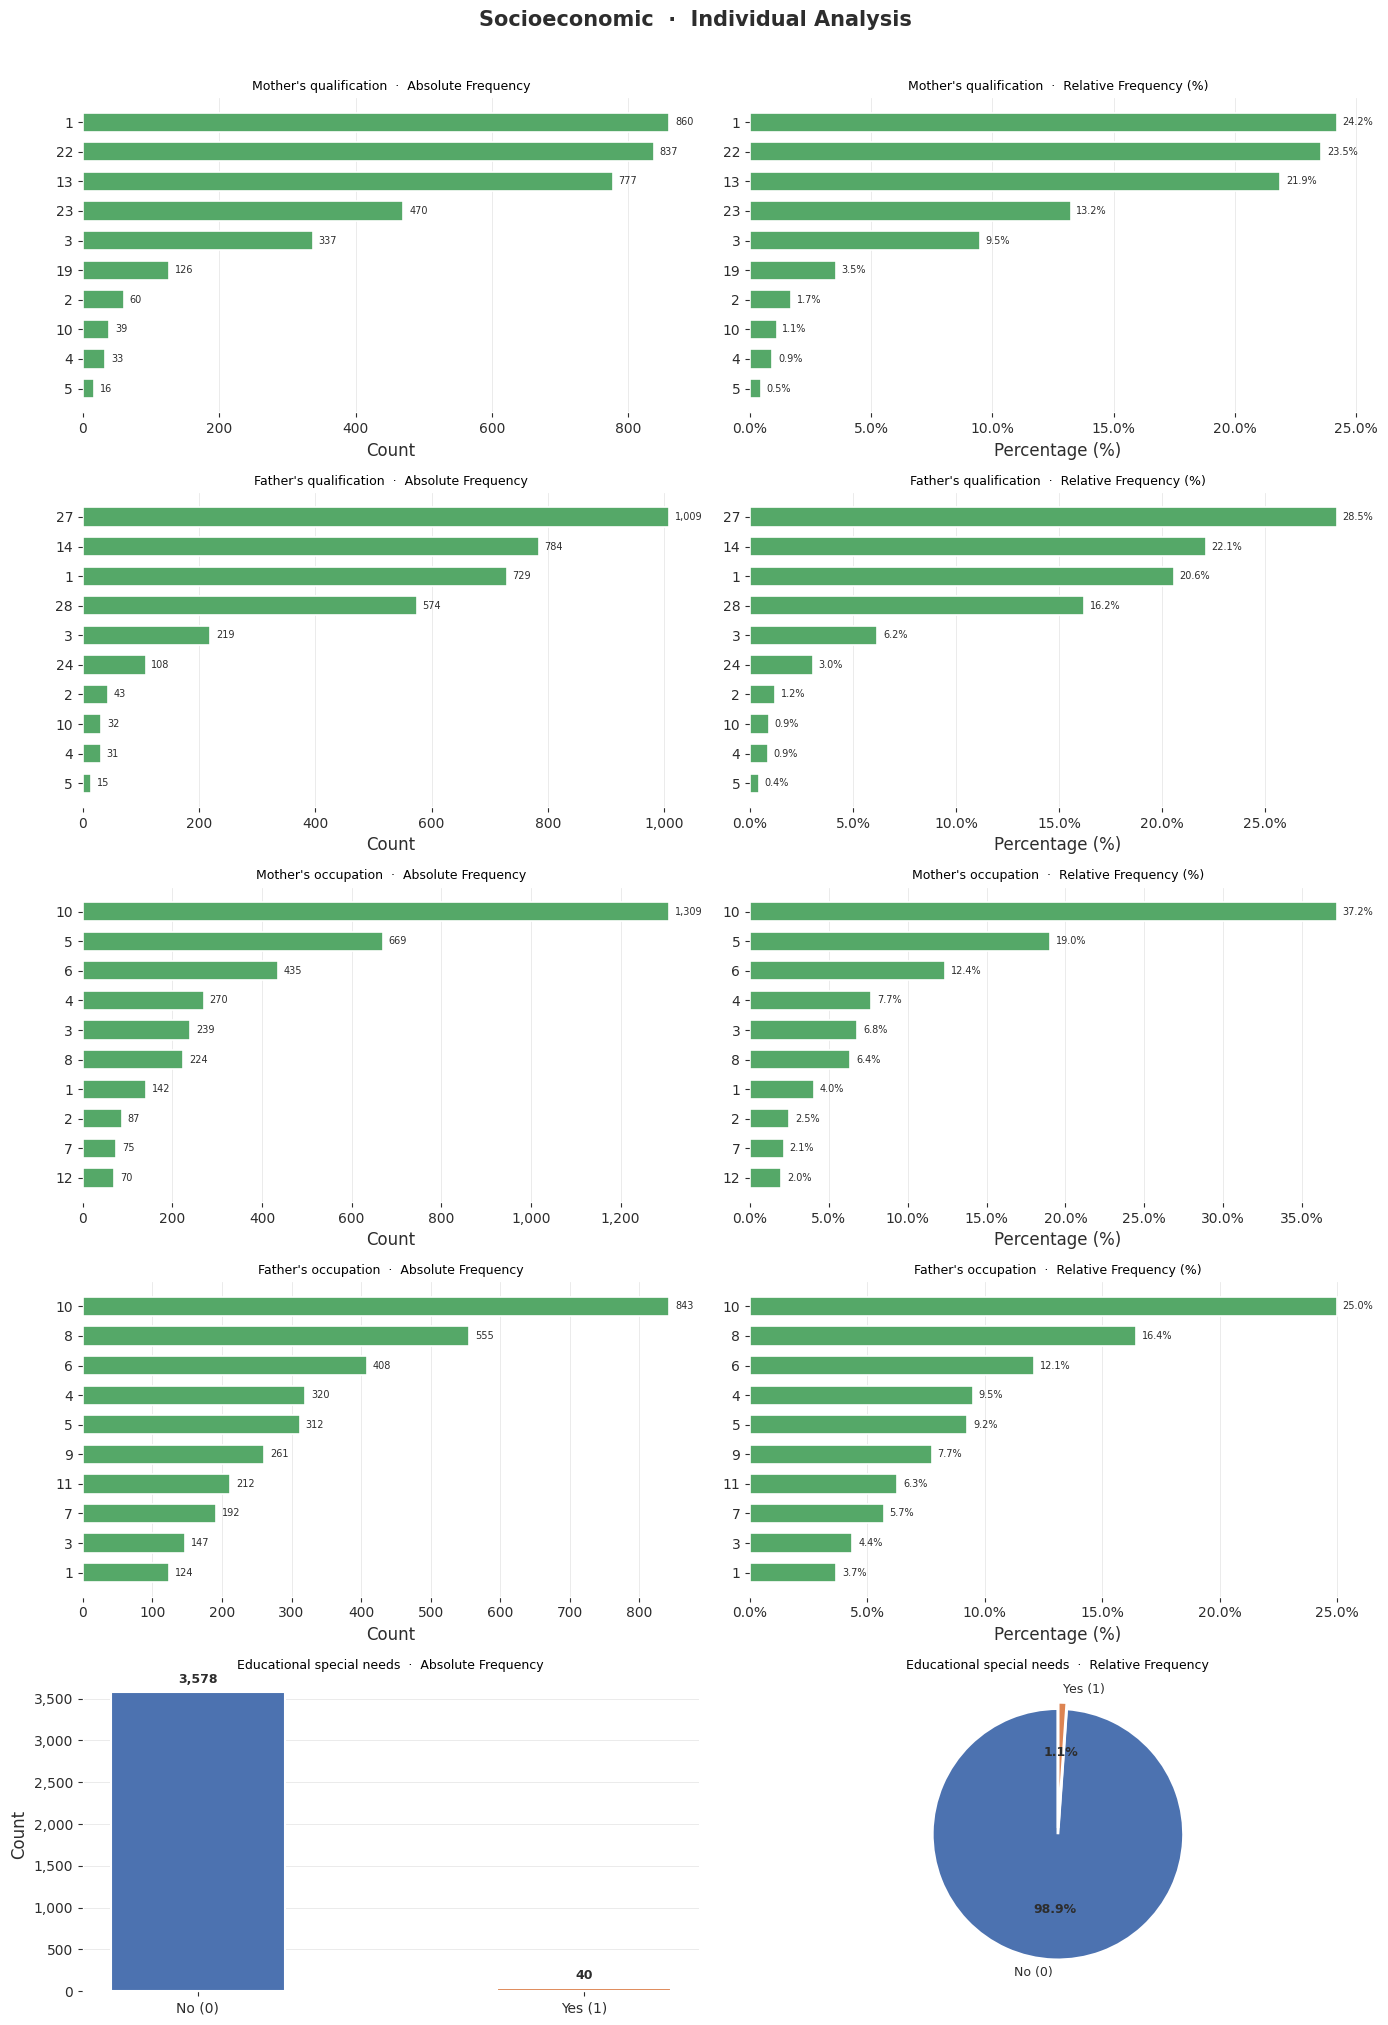

In [163]:
plot_group(df, socioeconomic,    group_name="Socioeconomic")

***Descriptive Analysis***

**Mother's qualification** spans 10 visible categories. Secondary Education 12th Year (code 1) leads at 24.2%, followed by General Commerce Course (code 22) at 21.5% and Basic Education 2nd Cycle (code 13) at 21.9%. Higher Education degree (code 3) accounts for 9.5%. The remaining codes each fall below 3.5%.

**Father's qualification** is concentrated in lower education levels. Basic Education 1st Cycle (code 27) dominates at 28.5%, followed by Basic Education 3rd Cycle (code 14) at 22.1% and Secondary Education (code 1) at 20.0%. Higher education codes (2, 3, 4, 5) collectively represent under 5%.

**Mother's occupation** is led by Unskilled Workers (code 10) at 37.7%, followed by Administrative Staff (code 5) at 19.0% and Personal Services and Sellers (code 6) at 12.4%. Professional categories (codes 2, 3) represent under 3% combined.

**Father's occupation** shows a broader spread across manual categories. Unskilled Workers (code 10) leads at 25.0%, followed by Skilled Industry and Construction Workers (code 8) at 18.4% and Personal Services (code 6) at 12.1%.

**Educational special needs** is near-constant — 98.9% of students (3,578) have no special needs, with only 40 (1.1%) flagged as Yes.

***Key Insights***

The socioeconomic profile of the modelling set is predominantly low to lower-middle class. Fathers skew toward basic education and manual trades; mothers toward secondary education and unskilled or administrative work. Educational special needs is near-constant and should be dropped, 40 positive cases are insufficient for reliable modelling. All four parental variables carry potential signal but require consolidation into broader tiers before modelling to eliminate sparse categories.

### 3.3 Enrollment & Application Profile

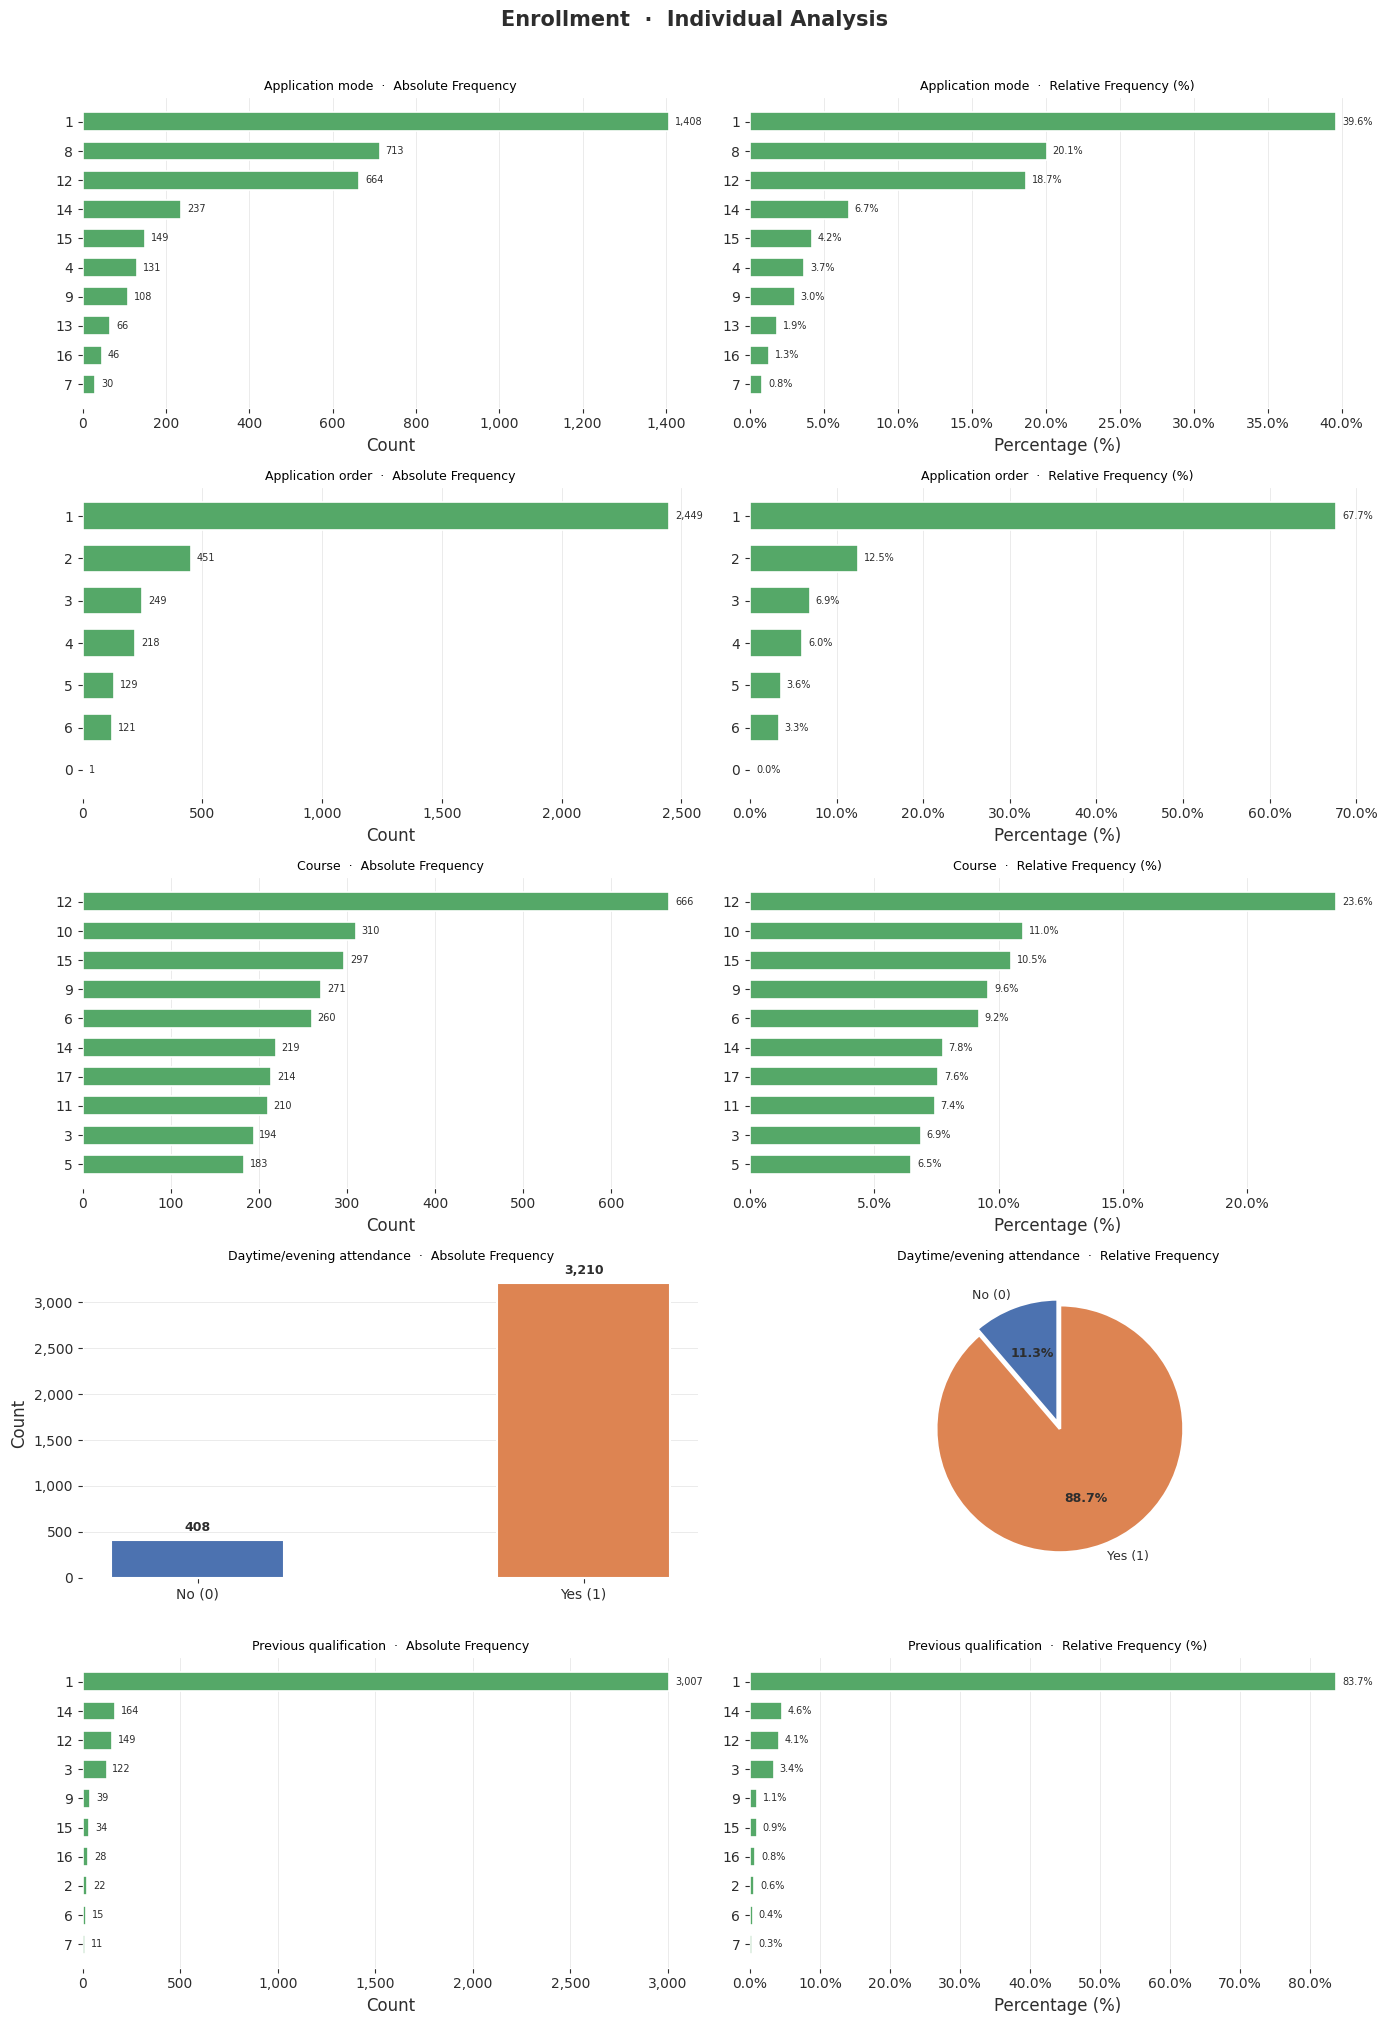

In [164]:
plot_group(df, enrollment,       group_name="Enrollment")

***Descriptive Analysis***

**Application mode** is dominated by three standard pathways: 1st phase general contingent (code 1) at 39.6%, 2nd phase (code 8) at 20.1%, and Over 23 years old (code 12) at 18.7%. Together these account for ~78% of the modelling set. Non-standard modes each fall below 6.7%.

**Application order** is heavily concentrated at first choice (code 1) at 67.7%, dropping sharply to 12.5% for second choice and under 7% for all subsequent ranks.

**Course** shows Nursing (code 12) leading at 23.6%, followed by Social Service (code 10) at 11.0% and Journalism and Communication (code 15) at 10.5%. The remaining 11 courses each represent under 10%.

**Daytime/evening attendance** is skewed toward daytime students (88.7%), with only 408 evening students (11.3%) in the modelling set.

**Previous qualification** is near-constant — Secondary Education (code 1) accounts for 83.7%, with Technological Specialisation (code 14) a distant second at 4.9%. All remaining codes fall below 4.1%.


***Key Insights***

**Previous qualification is near-constant** at 83.7% Secondary Education: consolidation into broader tiers is essential before modelling. **Course** is the most evenly distributed variable and likely the strongest enrollment predictor given discipline-level variation in dropout rates. **Application order** is highly skewed toward first choice but may still carry signal in lower ranks. **Daytime/evening attendance** retains its structural imbalance, since the 408 evening students represent a distinct at-risk profile worth preserving in the feature set despite the skew.

### 3.4 Financial Status

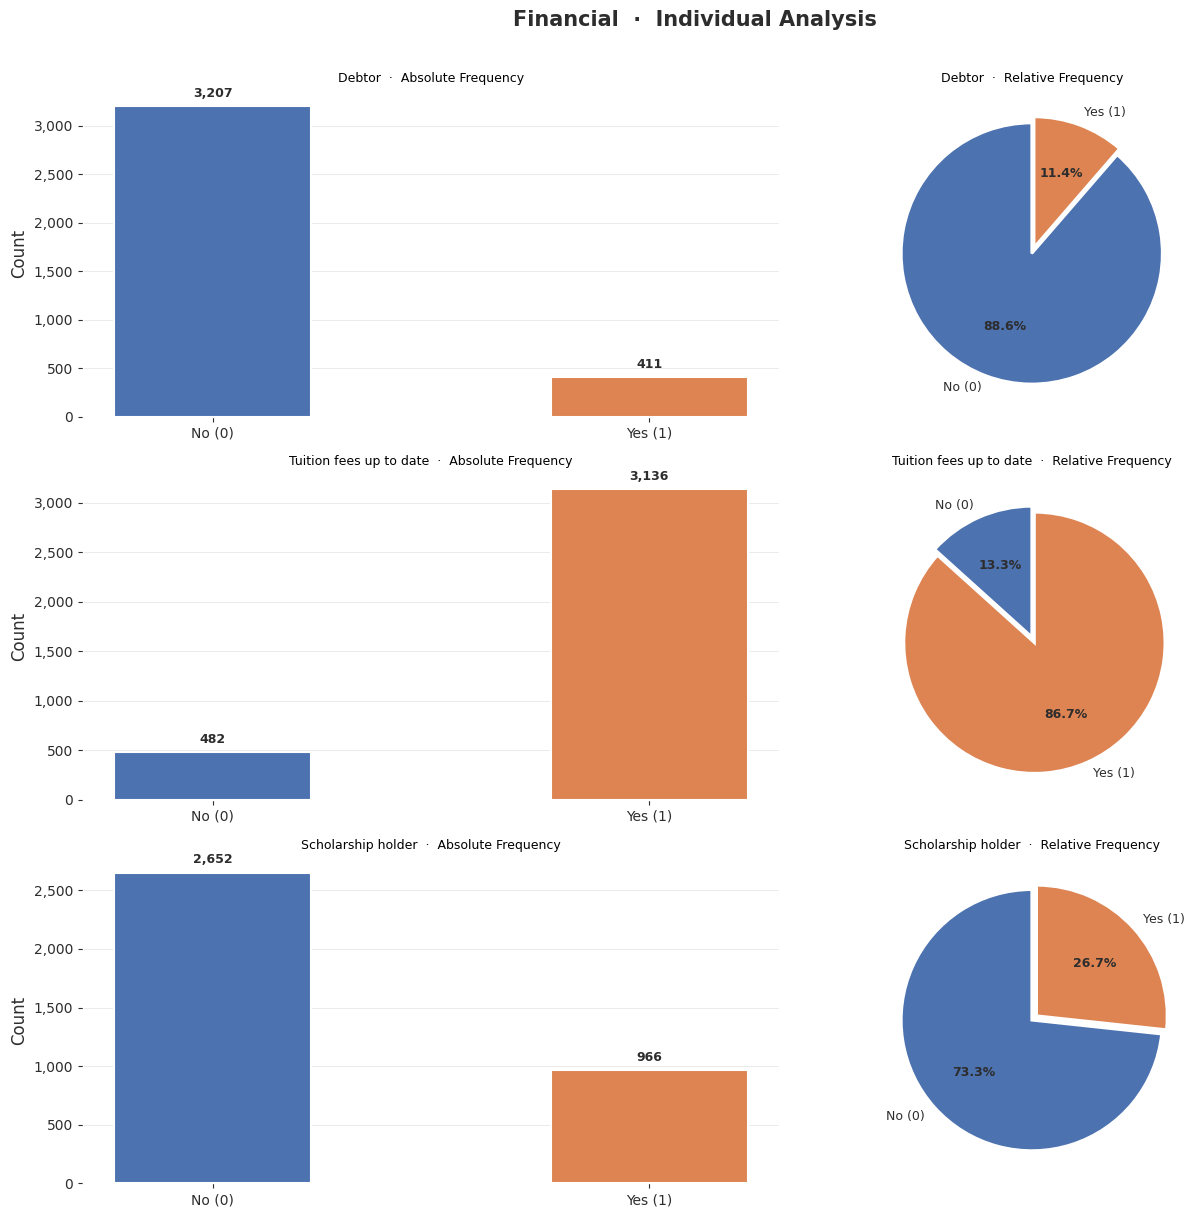

In [165]:
plot_group(df, financial,        group_name="Financial")

***Descriptive Analysis***

**Debtor** flags whether a student has outstanding fees. 88.6% of students are non-debtors, with only 11.4% carrying debt. Despite the imbalance, this variable is likely a strong dropout signal. Financial difficulty is one of the most well-documented drivers of student attrition.

**Tuition fees up to date** is the mirror image of Debtor: 86.7% of students have fees up to date (Yes), with 13.3% not. While the split appears almost identical to Debtor, the two variables are not redundant: Debtor captures historical debt while Tuition fees tracks current payment status. Together they define distinct levels of financial distress rather than duplicate information.

**Scholarship holder** shows that 73.3% of students do not hold a scholarship, with 26.1% receiving one. This is the most balanced of the three variables and the most useful socioeconomic proxy. Notably, scholarship status interacts with the other two. As seen on the clening part, 23 scholarship holders carry both old debt and unpaid current tuition, suggesting their partial funding is insufficient to cover full financial obligations.


***Key Insights***


The three variables define two financial distress profiles identified during data cleaning. The most severe cases: students with both historical debt and unpaid current tuition, including scholarship holders whose partial funding is insufficient — represent a small but acutely vulnerable group as we saw on the cleaning. A milder distress level is seen in students carrying old debt but remaining current on tuition. **All three variables are complementary rather than redundant**: Debtor captures historical obligation, Tuition fees tracks current payment status, and Scholarship holder acts as a socioeconomic proxy and protective factor. Together they form the basis of the financial distress score to be engineered in the next notebook.

### 3.5 1st Semester Academic Performance

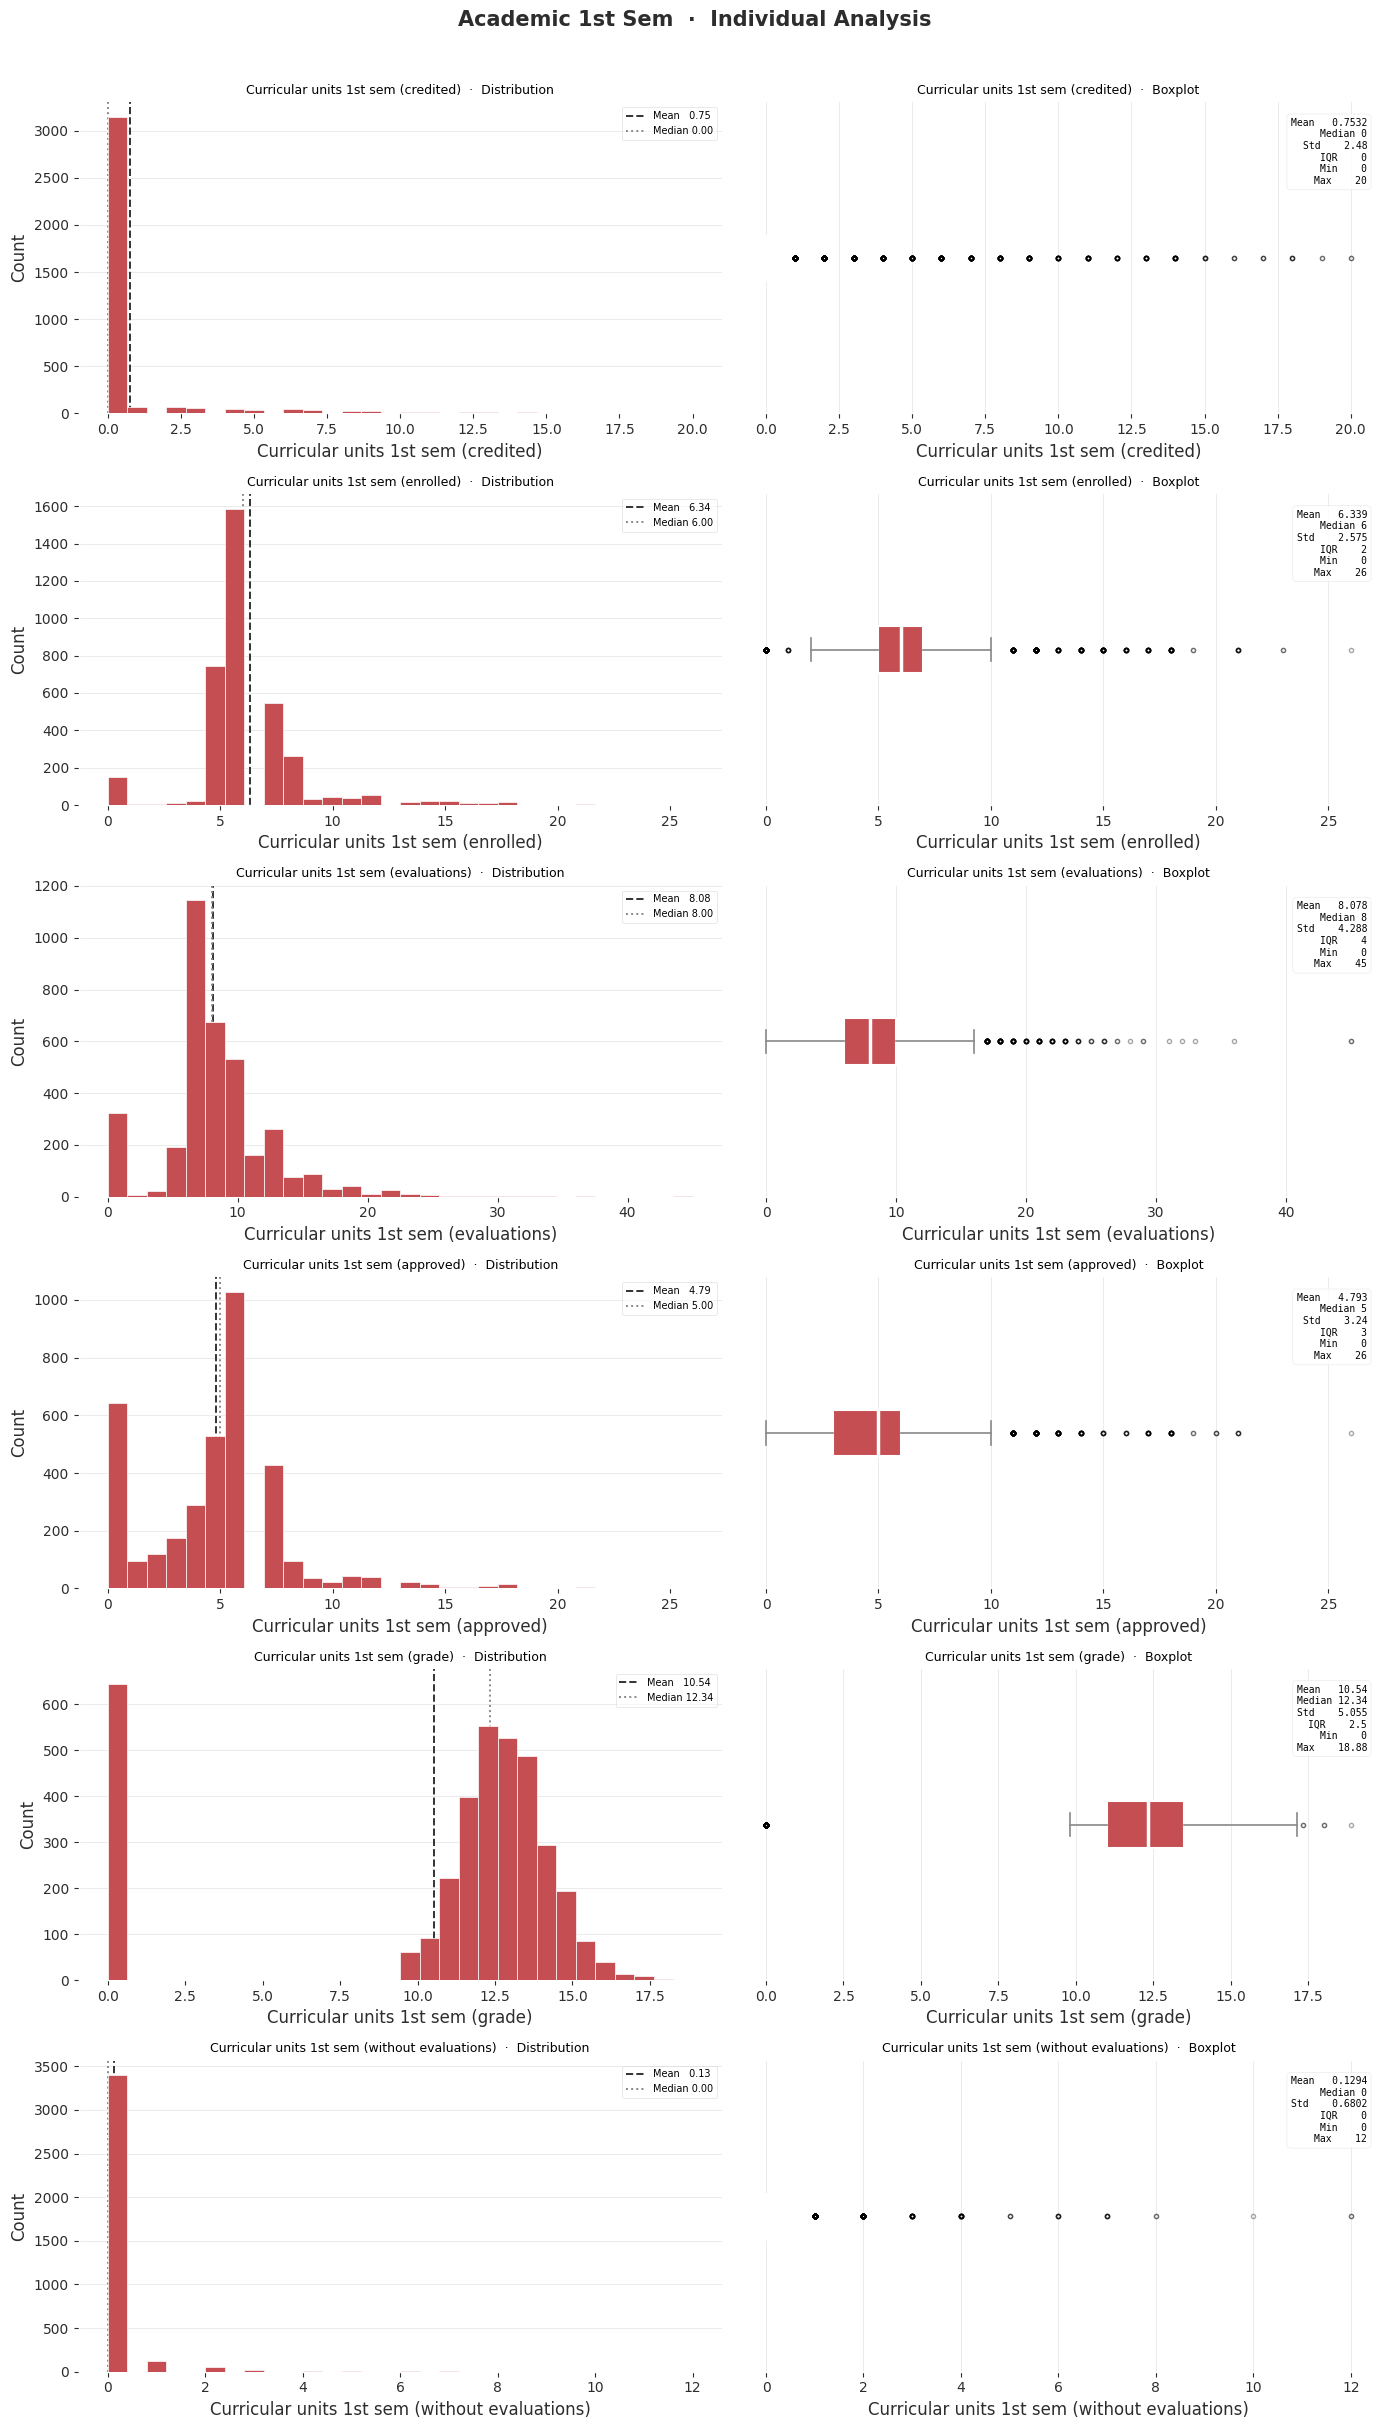

In [166]:
plot_group(df, academic_1st_sem, group_name="Academic 1st Sem")

***Descriptive Analysis***

**Curricular units credited** is heavily zero-inflated (median 0, mean 0.75) — the vast majority of students enter with no prior credits. The sparse right tail suggests converting this to a binary flag (credited / not) before modelling.

**Curricular units enrolled** is the most well-behaved variable in the group — approximately normal, centred around 5–6 units (mean 6.34, median 6, IQR 2). Usable as-is with minimal transformation needed.

**Curricular units evaluations** follows a similar shape (mean 9.08, median 8) but with a wider spread and a notable zero spike. Students with zero evaluations likely disengaged early and represent a high-risk subgroup worth flagging.

**Curricular units approved** shows a bimodal distribution — a zero cluster followed by a mode around 5 (mean 4.79, median 5). The zero group is analytically critical: students who enrolled but passed nothing in the first semester are strong dropout candidates.

**Curricular units grade** is the most normally distributed variable among non-zero entries (median 12.34), but carries a structural zero cluster from students with no approved units. These zeros are not true grades and should be handled separately in feature engineering.

**Curricular units without evaluations** is near-constant — the vast majority of students report zero (mean 0.13, median 0). It adds negligible signal in its raw form and is a candidate for removal or binary recoding.

***Key Insights***

This group contains the strongest potential predictors of dropout in the dataset. **Approved units** and **grade** are the core performance signals: the zero cluster in both variables likely maps directly to dropout and warrants close examination in the bivariate analysis. An **enrolled-to-approved ratio** is a natural feature engineering candidate, capturing academic struggle more precisely than either variable alone. **Credited** and **without evaluations** should be simplified to binary flags or dropped given their zero inflation.

### 3.6 Macroeconomic Context

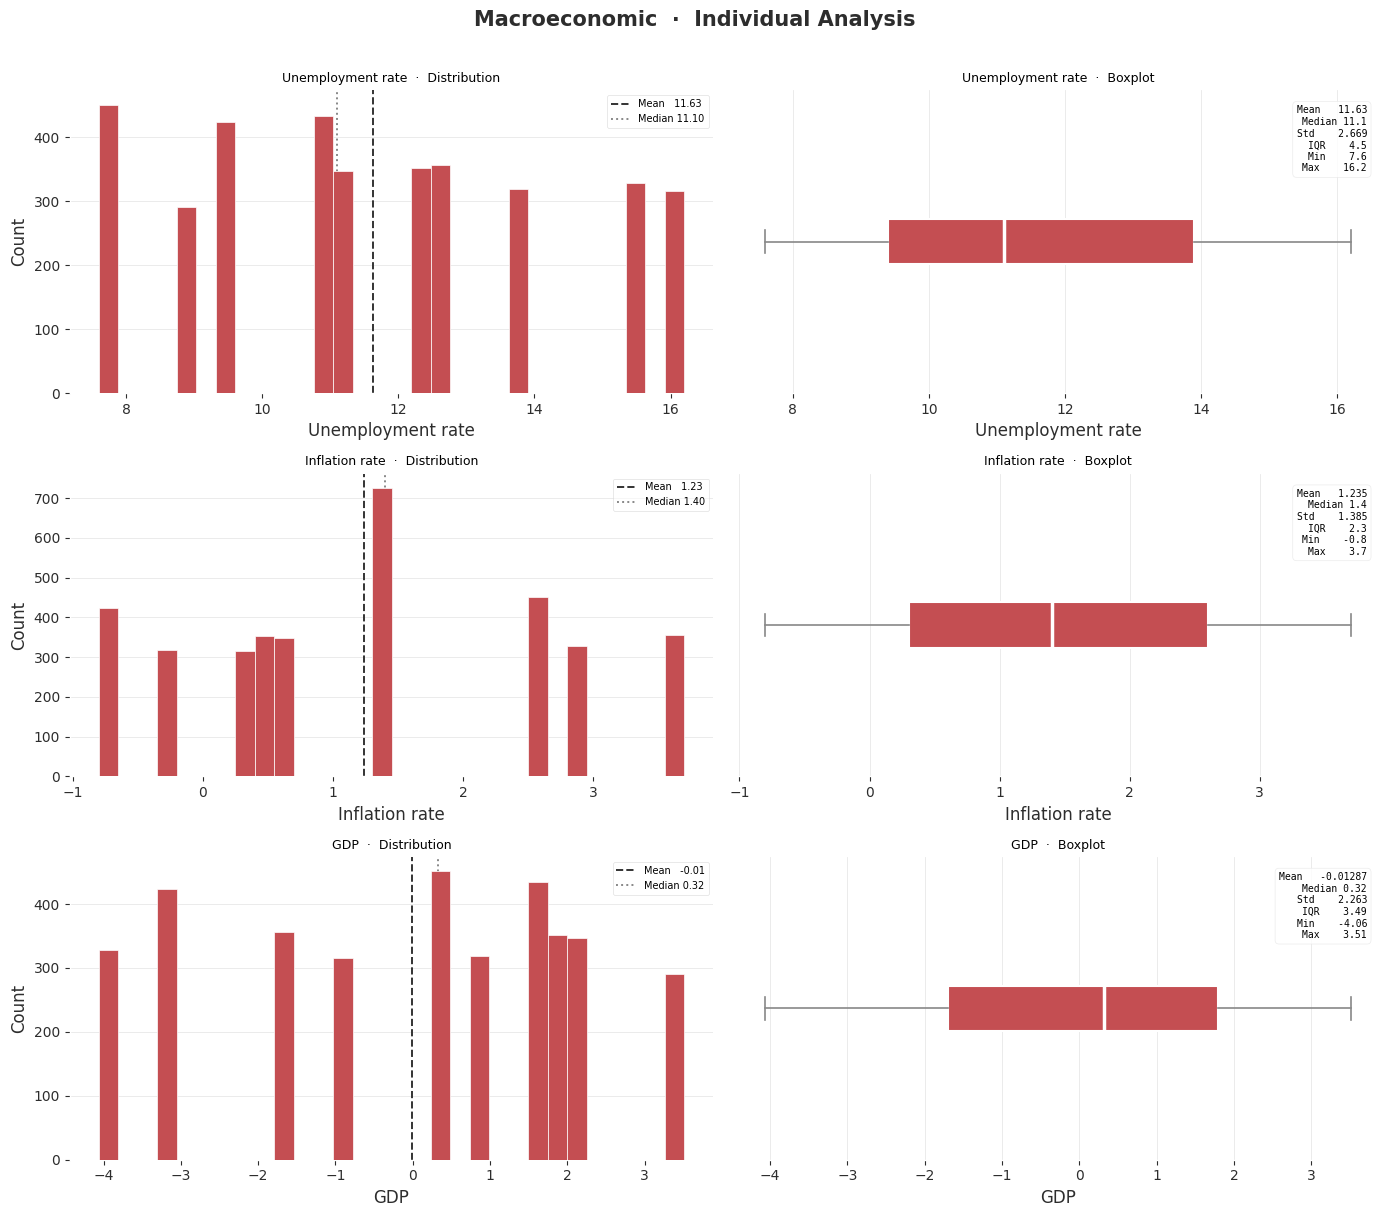

In [167]:
plot_group(df, macroeconomic,    group_name="Macroeconomic")

***Descriptive Analysis***

**Unemployment rate** ranges from approximately 7.6% to 16.2% (mean 11.63, median 11.1, IQR 4). The flat distribution confirms enrollment spans meaningfully different labour market conditions: from pre-crisis stability to peak austerity levels, giving this variable genuine predictive potential through its impact on household financial support.

**Inflation rate** ranges from approximately -1% to 3.7% (mean 1.23, median 1.4, IQR 2.3). Coverage of both deflationary and inflationary periods is confirmed. High inflation directly increases students' cost of living, compounding financial pressure on those already financially stretched.

**GDP growth** ranges from approximately -4.06% to 3.51% (mean ≈ -0.01, median 0.32, IQR 3.49). The symmetric spread across contraction and recovery phases reflects the full Portuguese economic cycle. During downturns, part-time job availability and scholarship budgets shrink, reducing the financial safety nets many students depend on.

***Key Insights***

The three variables capture the external financial environment students cannot control, complementing the individual-level financial indicators already in the dataset. Their relevance to dropout is indirect but important: high unemployment reduces family support, inflation erodes purchasing power, and GDP contraction shrinks student income opportunities. A student carrying personal financial distress during adverse macroeconomic conditions faces compounded dropout risk that neither dimension captures alone.

However, the near-identical distributions across all three confirm high multicollinearity. A correlation check is essential: if confirmed, retaining only unemployment rate as the most intuitive financial pressure proxy.

---

## 4. Bivariate Analysis: Features vs Target

The bivariate analysis examines how each variable relates to the dropout target, following the same six-group structure as the univariate section. For each variable, a shared helper function `plot_bivariate_group()` is used throughout: it automatically detects the variable type — binary, categorical, or continuous — and renders the appropriate pair of charts. Binary and categorical variables are displayed as a count bar chart alongside a 100% stacked distribution chart showing the dropout/graduate split per category; continuous variables are displayed as a boxplot alongside a violin plot, both split by target class. For categorical variables with more than 10 categories, 
the function retains the top 10 by frequency and consolidates the remainder into an "Other" group to keep the charts readable.

In [168]:
# ── Shared label map ──────────────────────────────────────────────────────────
TARGET_LABEL_MAP = {0: "Non-Dropout", 1: "Dropout"}


# ── Bivariate renderers ───────────────────────────────────────────────────────

def _render_binary_vs_target(ax_l, ax_r, series, target, col):
    cross     = pd.crosstab(series, target)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    classes   = cross.columns.tolist()
    colors    = [PALETTE["no"], PALETTE["yes"]]
    x         = np.arange(len(cross.index))
    width     = 0.35
    labels    = [TARGET_LABEL_MAP.get(c, str(c)) for c in classes]

    for i, (cls, color, lbl) in enumerate(zip(classes, colors, labels)):
        bars = ax_l.bar(x + i * width, cross[cls], width=width,
                        label=lbl, color=color,
                        edgecolor="white", linewidth=1.2, zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax_l.text(bar.get_x() + bar.get_width() / 2,
                          h + cross.values.max() * 0.015,
                          f"{int(h):,}", ha="center", va="bottom",
                          fontsize=7, color=PALETTE["text"])
    ax_l.set_title(f"{col}  ·  Count by Target", fontsize=9, pad=6)
    ax_l.set_xticks(x + width / 2)
    ax_l.set_xticklabels(cross.index.astype(str), fontsize=8)
    ax_l.set_ylabel("Count")
    ax_l.legend(title="Target", fontsize=7)
    ax_l.grid(axis="x", visible=False)

    bottom = np.zeros(len(cross_pct))
    for cls, color, lbl in zip(classes, colors, labels):
        vals = cross_pct[cls].values
        bars = ax_r.bar(x, vals, bottom=bottom, width=0.5,
                        label=lbl, color=color,
                        edgecolor="white", linewidth=1.2, zorder=3)
        for bar, val in zip(bars, vals):
            if val > 5:
                ax_r.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_y() + val / 2,
                          f"{val:.1f}%", ha="center", va="center",
                          fontsize=7, color="white", fontweight="bold")
        bottom += vals
    ax_r.set_title(f"{col}  ·  Target Distribution (%)", fontsize=9, pad=6)
    ax_r.set_xticks(x)
    ax_r.set_xticklabels(cross.index.astype(str), fontsize=8)
    ax_r.set_ylabel("Percentage (%)")
    ax_r.set_ylim(0, 100)
    ax_r.legend(title="Target", fontsize=7)
    ax_r.grid(axis="x", visible=False)


def _render_categorical_vs_target(ax_l, ax_r, series, target, col,
                                   max_categories=10):
    counts = series.value_counts()
    if len(counts) > max_categories:
        top_cats = counts.nlargest(max_categories).index
        series   = series.where(series.isin(top_cats), other="Other")

    cross     = pd.crosstab(series, target)
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    classes   = cross.columns.tolist()
    colors    = [PALETTE["no"], PALETTE["yes"]]
    x         = np.arange(len(cross.index))
    width     = 0.35
    labels    = [TARGET_LABEL_MAP.get(c, str(c)) for c in classes]

    for i, (cls, color, lbl) in enumerate(zip(classes, colors, labels)):
        bars = ax_l.bar(x + i * width, cross[cls], width=width,
                        label=lbl, color=color,
                        edgecolor="white", linewidth=1.2, zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h > cross.values.max() * 0.05:
                ax_l.text(bar.get_x() + bar.get_width() / 2,
                          h + cross.values.max() * 0.015,
                          f"{int(h):,}", ha="center", va="bottom",
                          fontsize=6, color=PALETTE["text"])
    ax_l.set_title(f"{col}  ·  Count by Target", fontsize=9, pad=6)
    ax_l.set_xticks(x + width / 2)
    ax_l.set_xticklabels(cross.index.astype(str),
                         rotation=35, ha="right", fontsize=7)
    ax_l.set_ylabel("Count")
    ax_l.legend(title="Target", fontsize=7)
    ax_l.grid(axis="x", visible=False)

    bottom = np.zeros(len(cross_pct))
    for cls, color, lbl in zip(classes, colors, labels):
        vals = cross_pct[cls].values
        bars = ax_r.bar(x, vals, bottom=bottom, width=0.5,
                        label=lbl, color=color,
                        edgecolor="white", linewidth=1.2, zorder=3)
        for bar, val in zip(bars, vals):
            if val > 5:
                ax_r.text(bar.get_x() + bar.get_width() / 2,
                          bar.get_y() + val / 2,
                          f"{val:.1f}%", ha="center", va="center",
                          fontsize=6, color="white", fontweight="bold")
        bottom += vals
    ax_r.set_title(f"{col}  ·  Target Distribution (%)", fontsize=9, pad=6)
    ax_r.set_xticks(x)
    ax_r.set_xticklabels(cross.index.astype(str),
                         rotation=35, ha="right", fontsize=7)
    ax_r.set_ylabel("Percentage (%)")
    ax_r.set_ylim(0, 100)
    ax_r.legend(title="Target", fontsize=7)
    ax_r.grid(axis="x", visible=False)


def _render_continuous_vs_target(ax_l, ax_r, series, target, col):
    classes = sorted(target.unique())
    colors  = [PALETTE["no"], PALETTE["yes"]]
    groups  = [series[target == c].dropna() for c in classes]
    labels  = [TARGET_LABEL_MAP.get(c, str(c)) for c in classes]

    bp = ax_l.boxplot(
        groups, patch_artist=True, vert=True, labels=labels,
        boxprops    =dict(linewidth=1.5),
        medianprops =dict(color="white", linewidth=2.5),
        whiskerprops=dict(color="#888",  linewidth=1.2),
        capprops    =dict(color="#888",  linewidth=1.2),
        flierprops  =dict(marker="o",    alpha=0.3, markersize=3),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax_l.set_title(f"{col}  ·  Boxplot by Target", fontsize=9, pad=6)
    ax_l.set_xlabel("Target_binary")
    ax_l.set_ylabel(col)
    ax_l.grid(axis="x", visible=False)

    parts = ax_r.violinplot(groups, showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(2)
    ax_r.set_xticks(range(1, len(classes) + 1))
    ax_r.set_xticklabels(labels)
    ax_r.set_title(f"{col}  ·  Violin by Target", fontsize=9, pad=6)
    ax_r.set_xlabel("Target_binary")
    ax_r.set_ylabel(col)
    ax_r.grid(axis="x", visible=False)


# ── User-facing function ──────────────────────────────────────────────────────

def plot_bivariate_group(df, variables, group_name="", max_categories=10):
    """Plot all variables in a group against Target_binary in a single figure."""
    if err := _validate(df, "Target_binary"):
        return _warn(err)

    target = df["Target_binary"]
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 2, figsize=(14, n_vars * 4))
    fig.suptitle(f"{group_name}  ·  Bivariate Analysis vs Target",
                 fontsize=15, fontweight="bold", color=PALETTE["text"], y=1.01)

    if n_vars == 1:
        axes = [axes]

    for row, col in enumerate(variables):
        if err := _validate(df, col):
            _warn(err)
            continue

        series   = df[col].dropna()
        var_type = _get_var_type(col, series)
        ax_l     = axes[row][0]
        ax_r     = axes[row][1]
        tgt      = target[series.index]

        if var_type == "binary":
            _render_binary_vs_target(ax_l, ax_r, series, tgt, col)
        elif var_type == "categorical":
            _render_categorical_vs_target(ax_l, ax_r, series, tgt, col,
                                          max_categories)
        else:
            _render_continuous_vs_target(ax_l, ax_r, series, tgt, col)

    fig.tight_layout()
    plt.show()

In [169]:
print(df['Target_binary'].unique())

[1 0]


### 4.1 Demographic & Personal Background vs Target

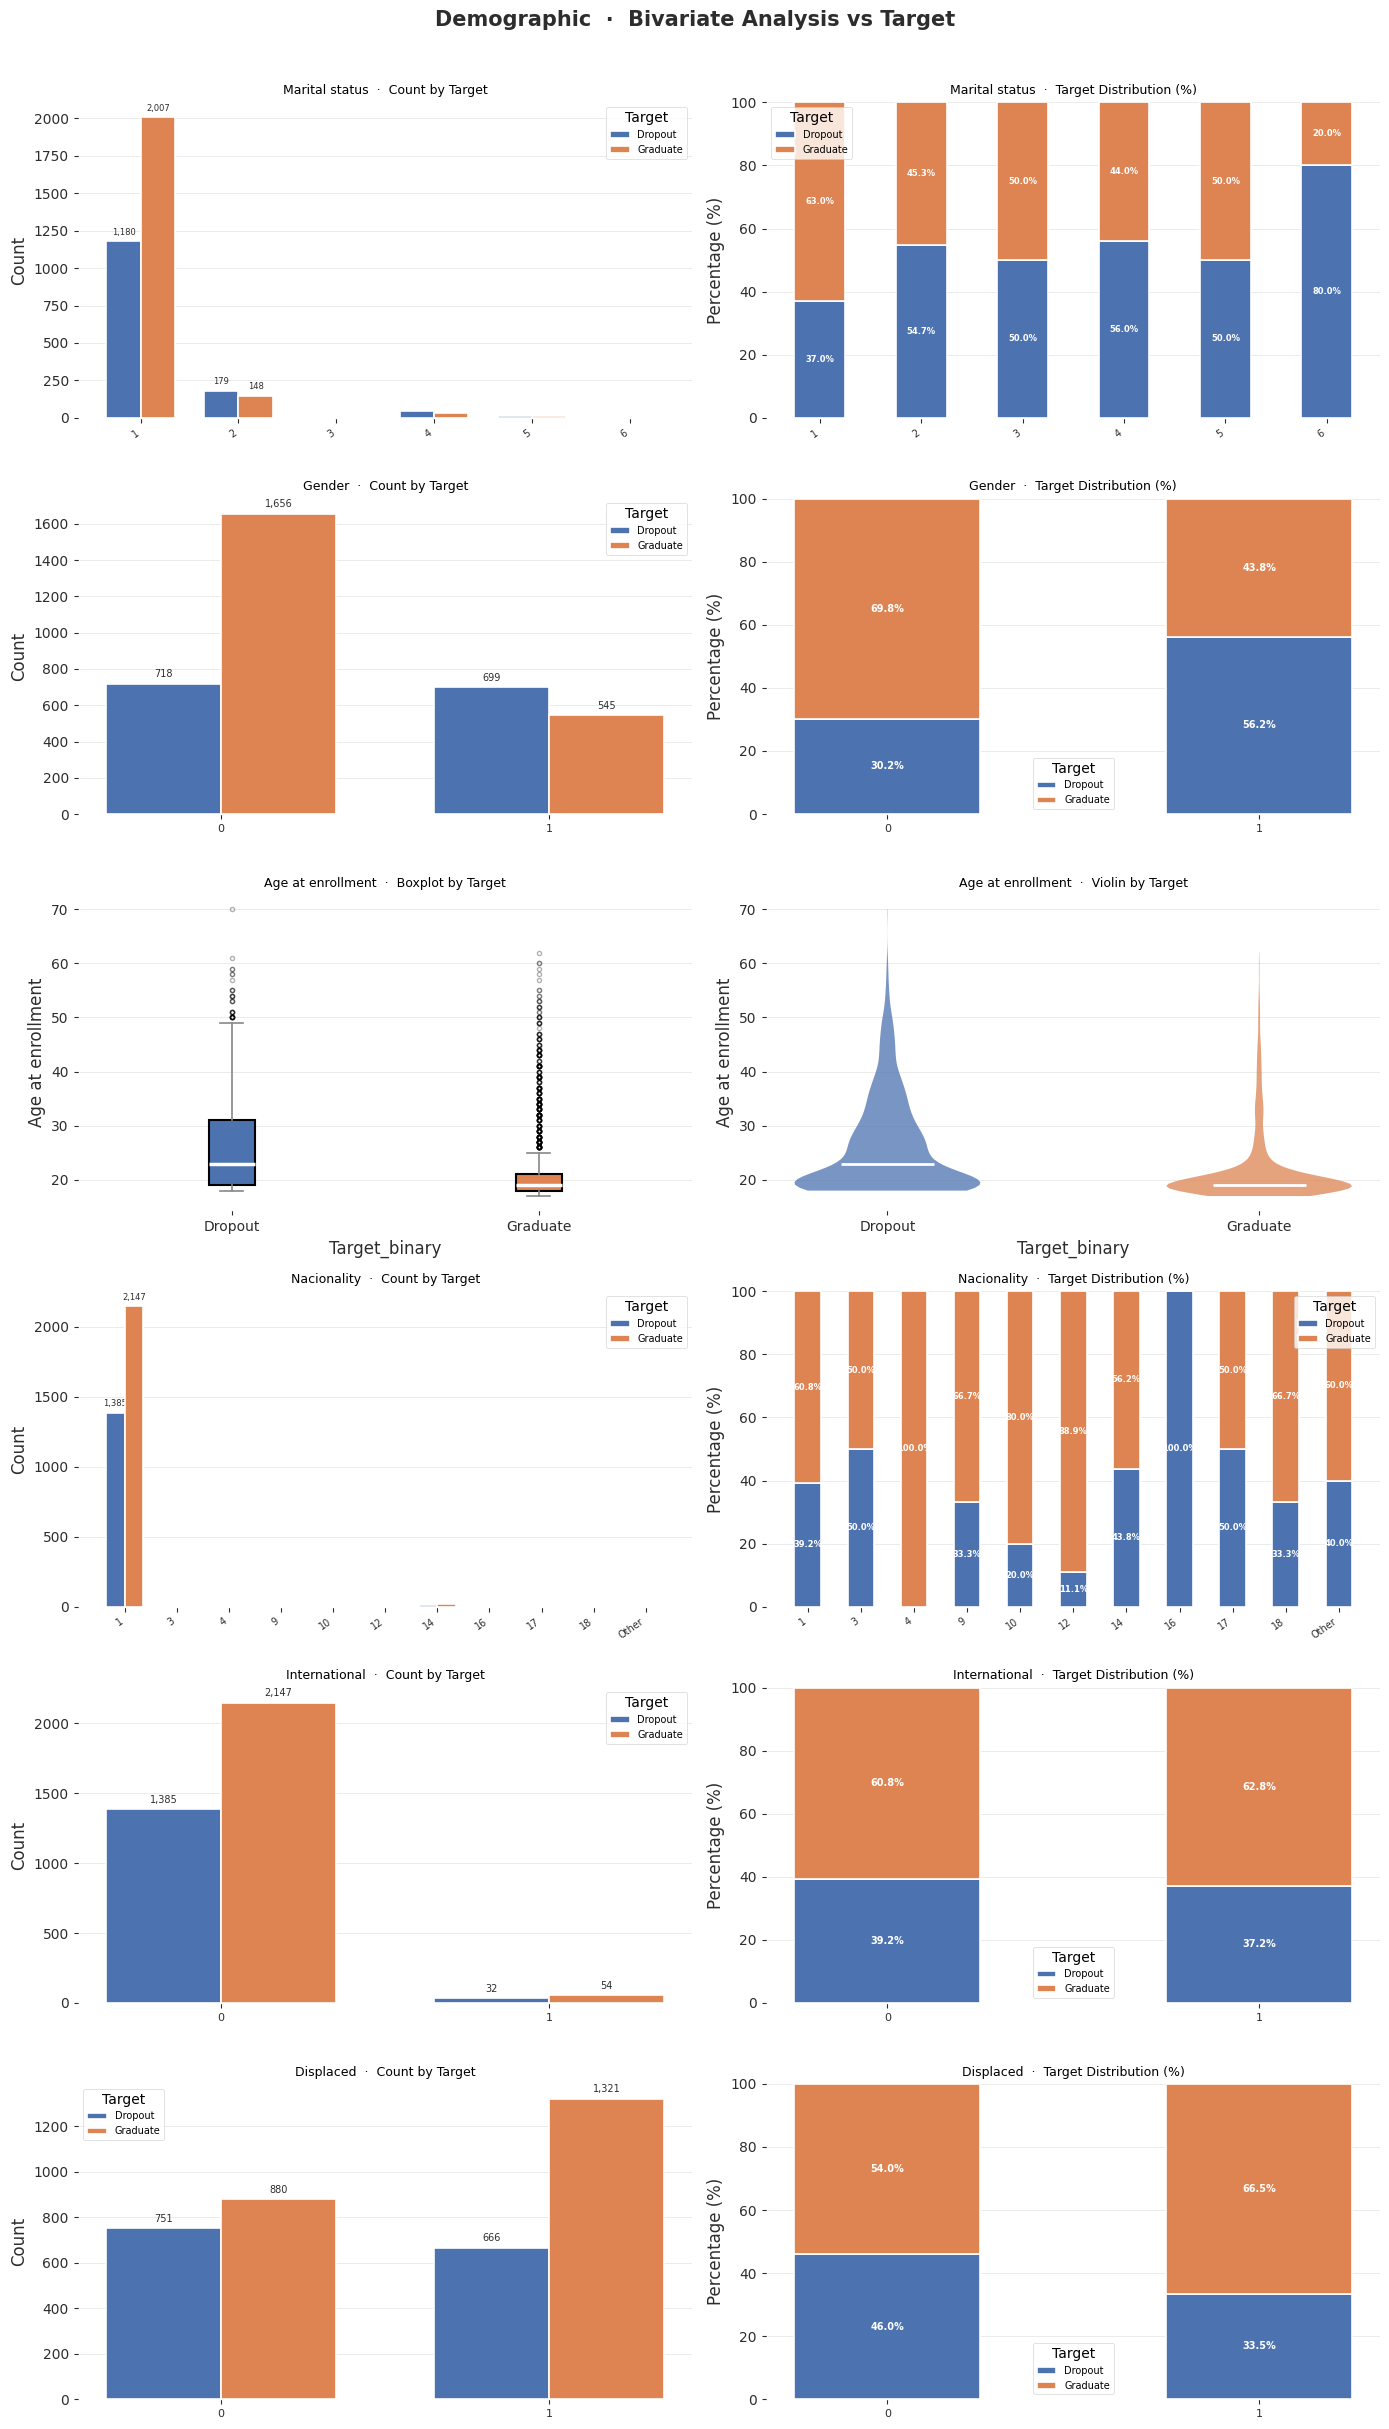

In [170]:
plot_group_with_target(df, demographic,     group_name="Demographic")

***Descriptive Analysis***

**Marital status** — Single students (code 1) show the lowest dropout rate at 27%, while Married students (code 2) show a notably higher 45.3%, contrary to the intuition that family commitment supports persistence. Codes 4 and 6 show dropout rates of 44.9% and 80% respectively, though their small sample sizes make these figures unreliable. Minority categories should be consolidated before modelling.

**Gender** — Female students (code 0) have a 30.2% dropout rate compared to 56.2% for male students (code 1). The absolute counts confirm this is not an artefact of class imbalance.

**Age at enrollment** — dropout students are older on average, with a wider and more right-skewed distribution. Graduates cluster tightly around 18–22, while dropouts show a heavier presence among mature students, visible in both the boxplot and violin plots.

**Nationality** — dropout rates vary across codes but sample sizes outside code 1 (Portuguese, n ≈ 2,167) are too small to draw reliable conclusions. The collapsed "Other" category sits at approximately 38.3%, broadly in line with the Portuguese majority at 28.2%.

**International** — dropout rates are near-identical between domestic (39.2%) and international students (37.2%). With only 86 international students total, this variable carries insufficient sample size for reliable inference.

**Displaced** — non-displaced students show a higher dropout rate (45.4%) than displaced students (33.5%), a counterintuitive finding that likely reflects confounding with age or course type rather than a genuine protective effect.

***Key Insights***

**Gender is the strongest demographic predictor** — a 26-point dropout rate gap between male and female students is substantial and consistent. **Age at enrollment** is the second most informative variable, confirming that mature students face higher dropout risk. **Marital status** shows variation across categories but the signal is partly driven by small subgroups; the single category dominates the dataset and its 27% dropout rate sets the baseline. **Displaced** and **International** show no meaningful discriminative power against the target and are strong candidates for removal.

### 4.2 Socioeconomic & Family Background vs Target

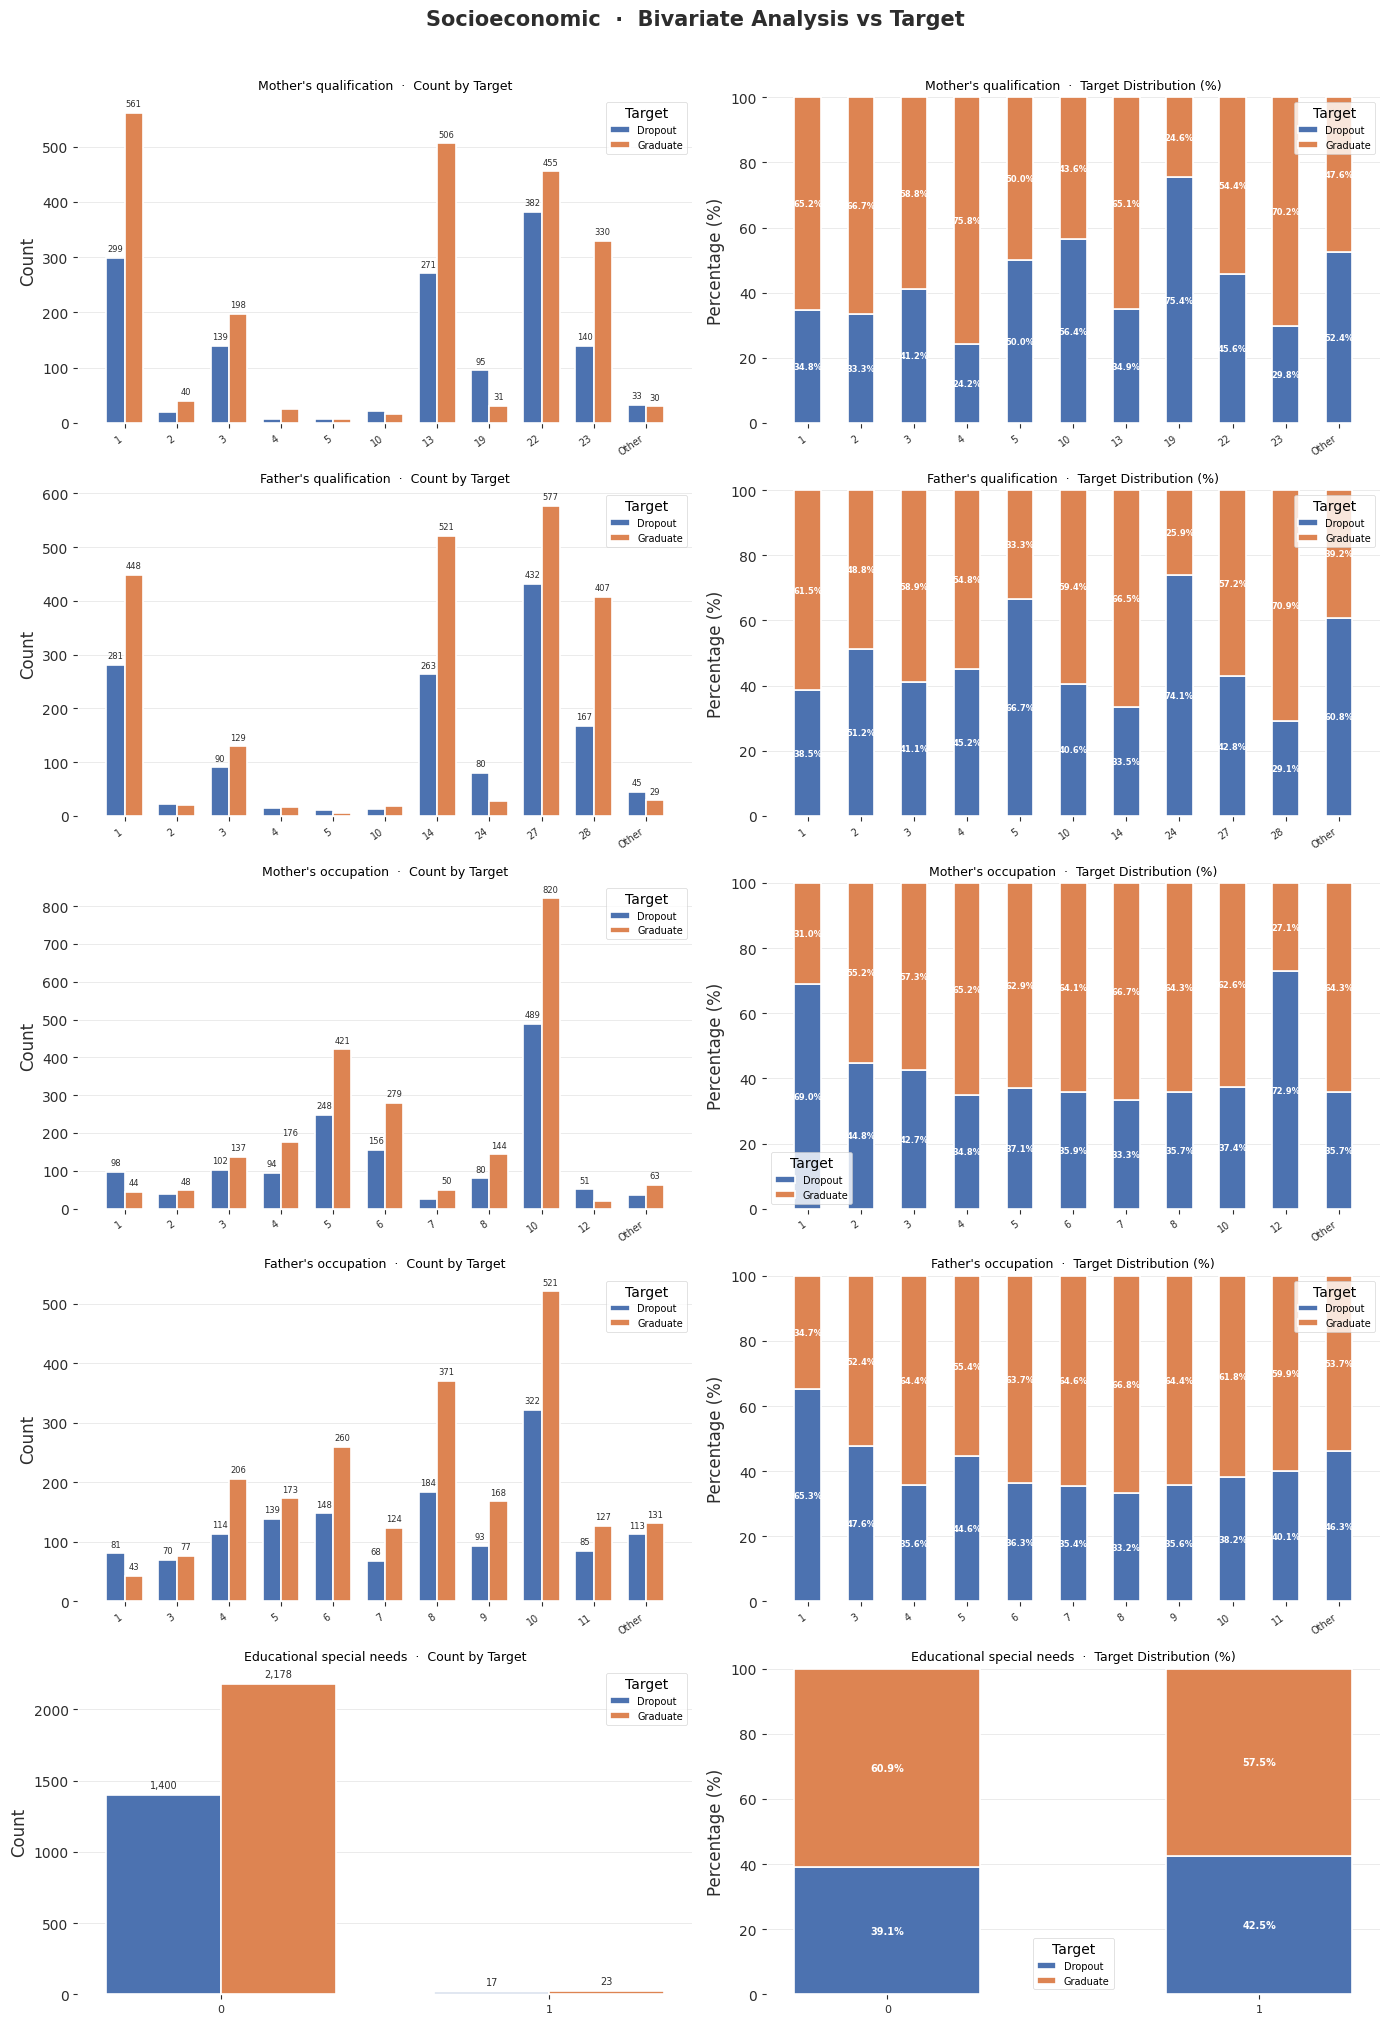

In [171]:
plot_group_with_target(df, socioeconomic,   group_name="Socioeconomic")

***Descriptive Analysis***

**Mother's qualification** — Students whose mothers hold Secondary Education (code 1) show a ~34.8% dropout rate, while those with Higher Education degrees show notably lower rates, some reaching as low as 19–25%, suggesting maternal education level is inversely related to dropout risk. Codes with very low sample sizes show erratic rates and should be consolidated before modelling.

**Father's qualification** — A similar gradient emerges, though less clean. Students whose fathers hold Basic Education show dropout rates around 38–40%, while those with Higher Education qualifications tend toward the lower end of the range. The direction is consistent with the maternal qualification finding, reinforcing the socioeconomic signal, even if individual category rates fluctuate due to small samples.

**Mother's occupation** — The sharpest contrast in the group. Unskilled Workers (code 10) shows a dropout rate around 70.9%, while professional categories such as Specialists in Intellectual and Scientific Activities (code 3) sit around 29.2%. The occupational gradient is steep and aligns closely with the qualification pattern.

**Father's occupation** — Consistent with mother's occupation. Unskilled and manual trade categories show elevated dropout rates, while managerial and specialist roles sit lower, around 30–35%. The gradient mirrors the maternal occupation finding across both direction and magnitude.

**Educational special needs** — Dropout rates are nearly identical between students without (39.1%) and with (42.5%) special needs. With only 40 students flagged as Yes, this variable lacks statistical power and should be dropped.

***Key Insights***

**Parental education and occupation carry consistent and interpretable signal**: higher parental qualification and occupational status correlates with lower student dropout across all four variables. This confirms the socioeconomic vulnerability hypothesis — students from lower-educated, lower-skilled family backgrounds face meaningfully higher dropout risk. The occupational contrast is particularly stark for mothers, where unskilled workers produce a dropout rate more than double that of professional categories. The four variables are worth retaining but consolidating into broader tiers will improve model reliability by eliminating sparse categories. **Educational special needs shows no discriminative power** and is a strong candidate for removal.

### 4.3 Enrollment & Application Profile vs Target


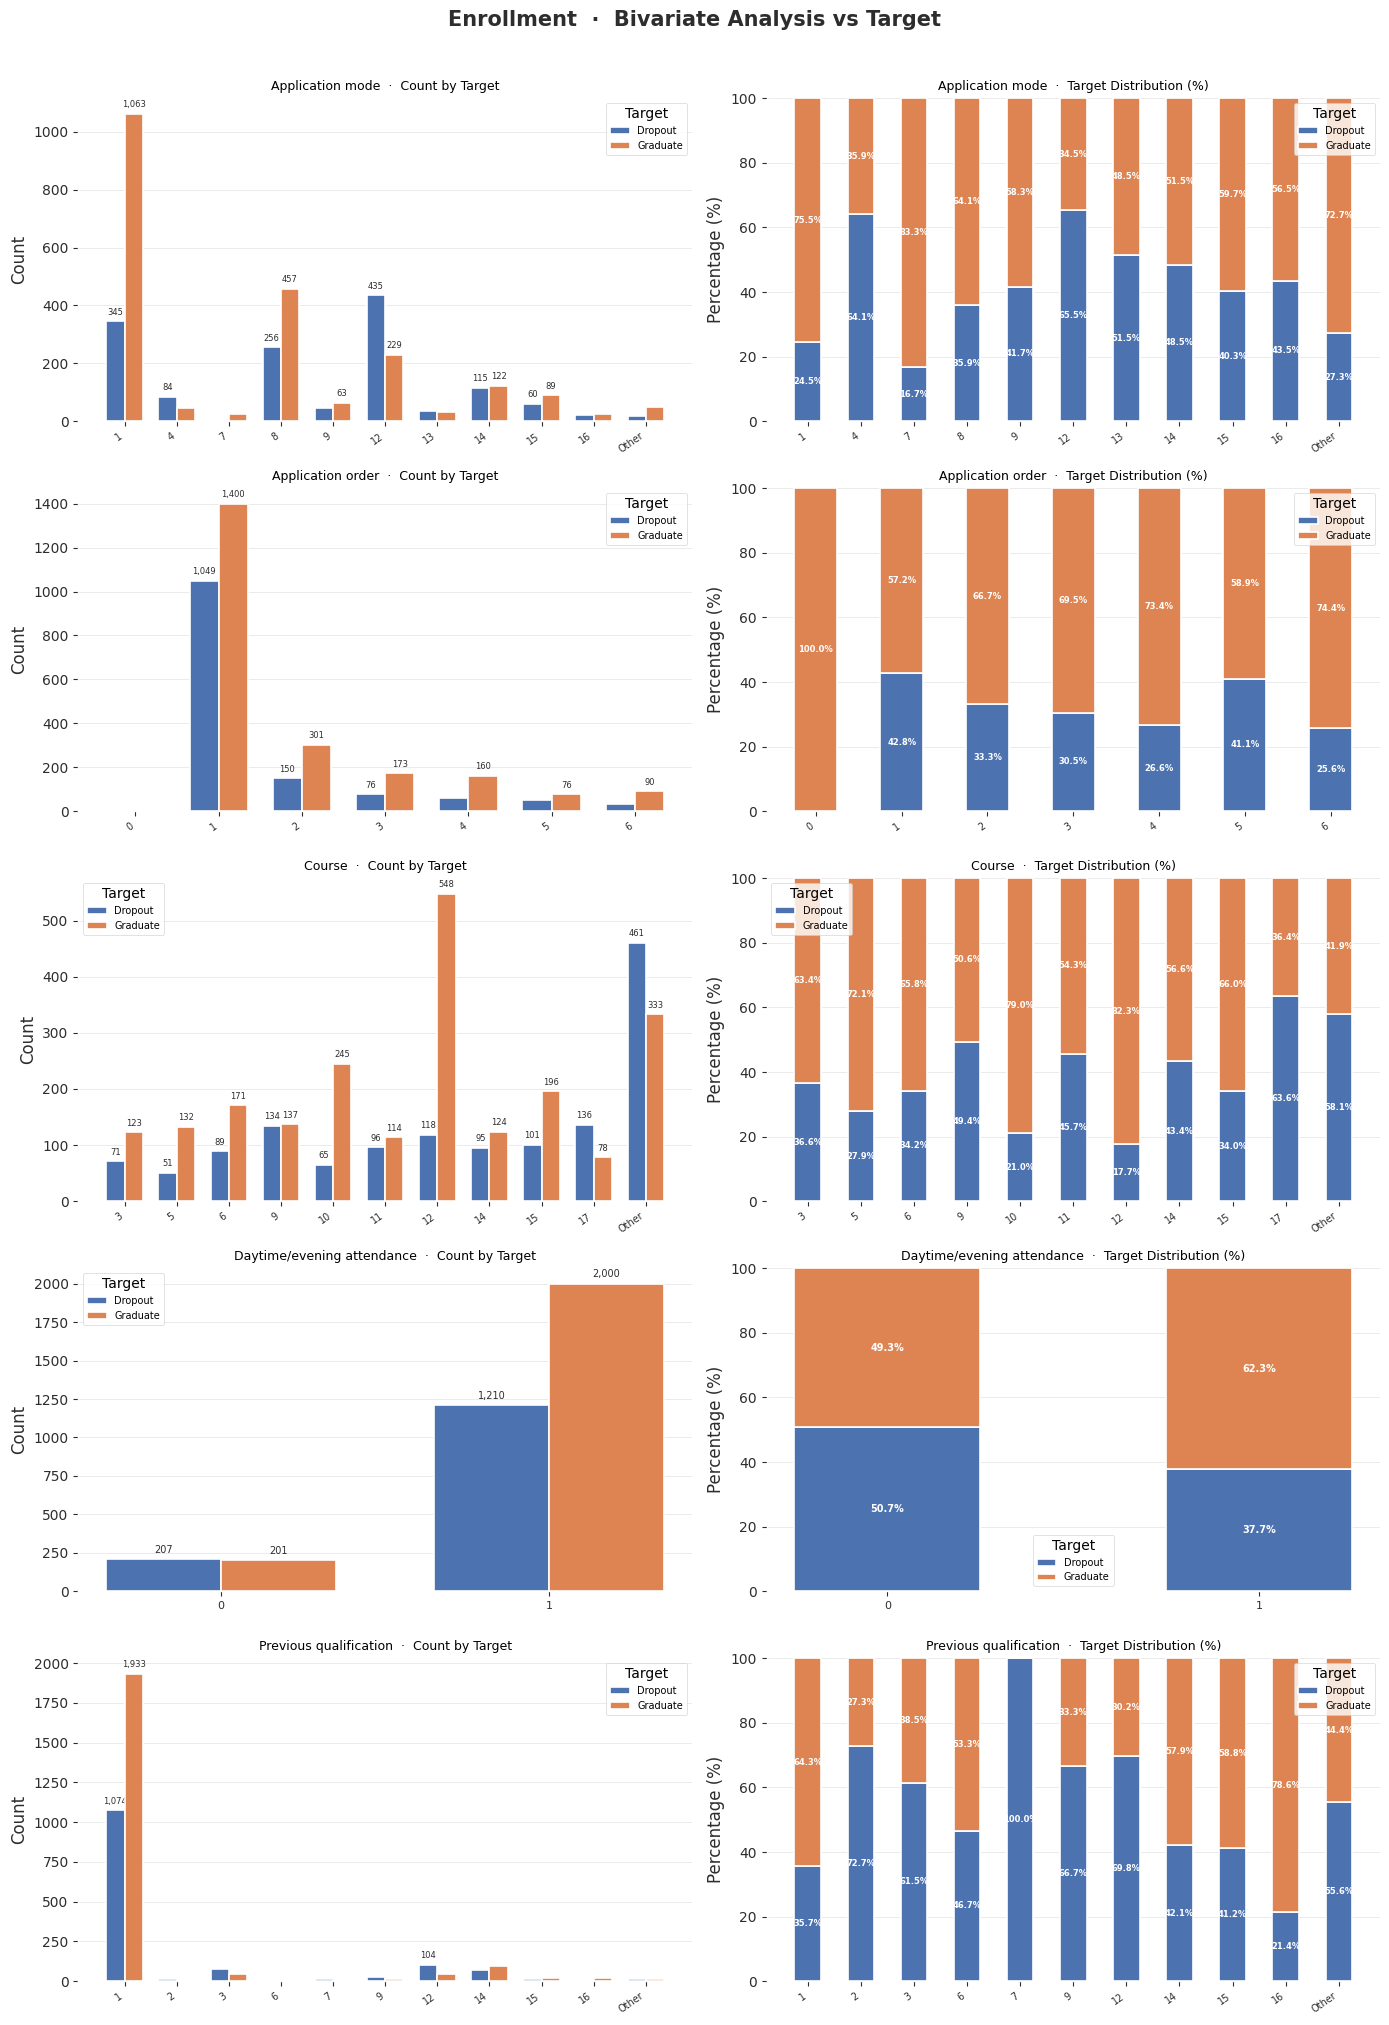

In [172]:
plot_group_with_target(df, enrollment,      group_name="Enrollment")

***Descriptive Analysis***

**Application mode** — Standard entry pathways show meaningfully different dropout rates. The 1st phase general contingent (code 1) sits at 24.5%, while the Over 23 years old pathway (code 7) shows 55.9% and code 8 reaches 63.6%, consistent with the age finding from the demographic analysis. Codes 11 and 12 also show elevated rates around 61%, suggesting non-standard and mature-entry students face substantially higher attrition risk. International student pathways show high dropout rates but with negligible sample sizes.

**Application order** — The pattern is non-linear. Students who listed the course as their zeroth preference show the highest dropout at 57.2%, while first-choice applicants sit at 42.8%. Rates then decline through orders 2–4 (33–40%), with order 6 showing the lowest at 25.6%. Students who secured a lower-preference placement may bring different motivational profiles that warrant further investigation before deciding whether to retain this variable.

**Course** — Substantial variation across programmes is visible. Some courses show dropout rates above 60% while others, such as those clustering in the lower bands, sit closer to 20–30%. Course is confirmed as a strong predictor, reflecting discipline-specific academic demands and student profiles.

**Daytime/evening attendance** — Evening students (code 0) show a notably higher dropout rate at 50.7% versus 37.7% for daytime students (code 1), consistent with the expected profile of evening students as older, employed, and facing competing life demands.

**Previous qualification** — Secondary education (code 1) shows a 29.7% dropout rate. Vocational and non-standard qualifications show elevated rates — code 12 reaches 66.7% and code 3 sits at 41.5% — indicating that students entering with incomplete or non-standard prior education face significantly higher attrition risk. Code 6 shows 100% dropout but with a negligible sample size, making it unreliable.

***Key Insights***

**Previous qualification and application mode are the strongest signals in this group.** Students entering through non-standard or mature-entry pathways show dropout rates more than double those of standard entrants. **Course is also a high-value predictor**, with clear discipline-level variation unlikely to be captured by other variables. **Daytime/evening attendance** confirms its relevance, with evening students crossing the 50% dropout threshold. The **application order** gradient is non-linear and counterintuitive in places: it warrants further investigation before deciding whether to retain it as a continuous or categorical feature.

### 4.4 Financial Status vs Target

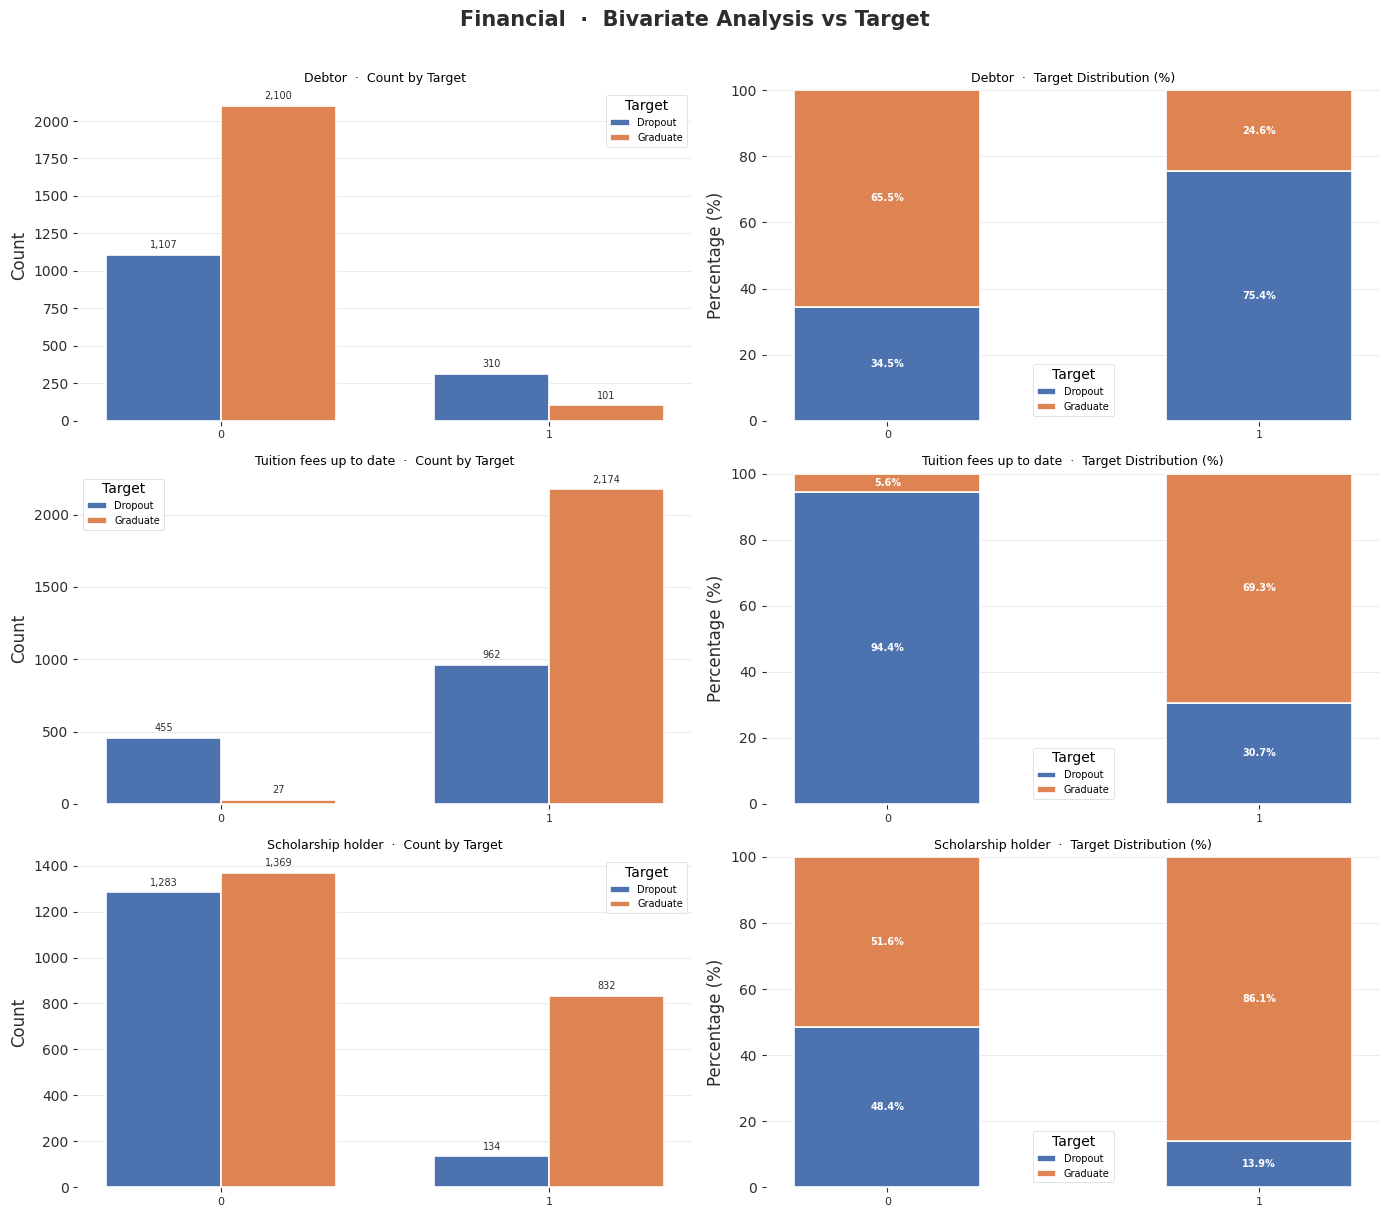

In [173]:
plot_group_with_target(df, financial,       group_name="Financial")

***Descriptive Analysis***

**Debtor** — Non-debtors (code 0) show a 36.5% dropout rate, while debtors (code 1) show a dramatically higher rate at 75.4%. Students carrying historical debt are more than twice as likely to drop out, making this one of the strongest individual predictors identified so far.

**Tuition fees up to date** — Students with fees up to date (code 1) show a 30.7% dropout rate, while those with overdue fees (code 0) show an overwhelming 94.4% dropout rate. This is the strongest binary signal in the entire dataset — nearly 19 in 20 students with unpaid current tuition drop out.

**Scholarship holder** — Non-scholarship students (code 0) show a 48.4% dropout rate, while scholarship holders (code 1) show a notably lower rate of 13.9%. Scholarship status acts as a strong protective factor, likely by relieving financial pressure and maintaining enrollment incentives.

***Key Insights***

**Financial variables are among the most powerful predictors in the dataset.** Tuition fees up to date alone achieves near-perfect separation — a 94.4% dropout rate among students with overdue fees leaves almost no ambiguity. Debtor status confirms the pattern from a complementary angle, with a 75.4% dropout rate among debtors. Scholarship holder reinforces the picture from the opposite direction, cutting the dropout rate to 13.9%. Together, these three variables define a clear financial distress profile that maps directly to dropout risk, and a composite financial distress score engineered from them is strongly justified by the bivariate evidence.

### 4.5 1st Semester Academic Performance vs Target


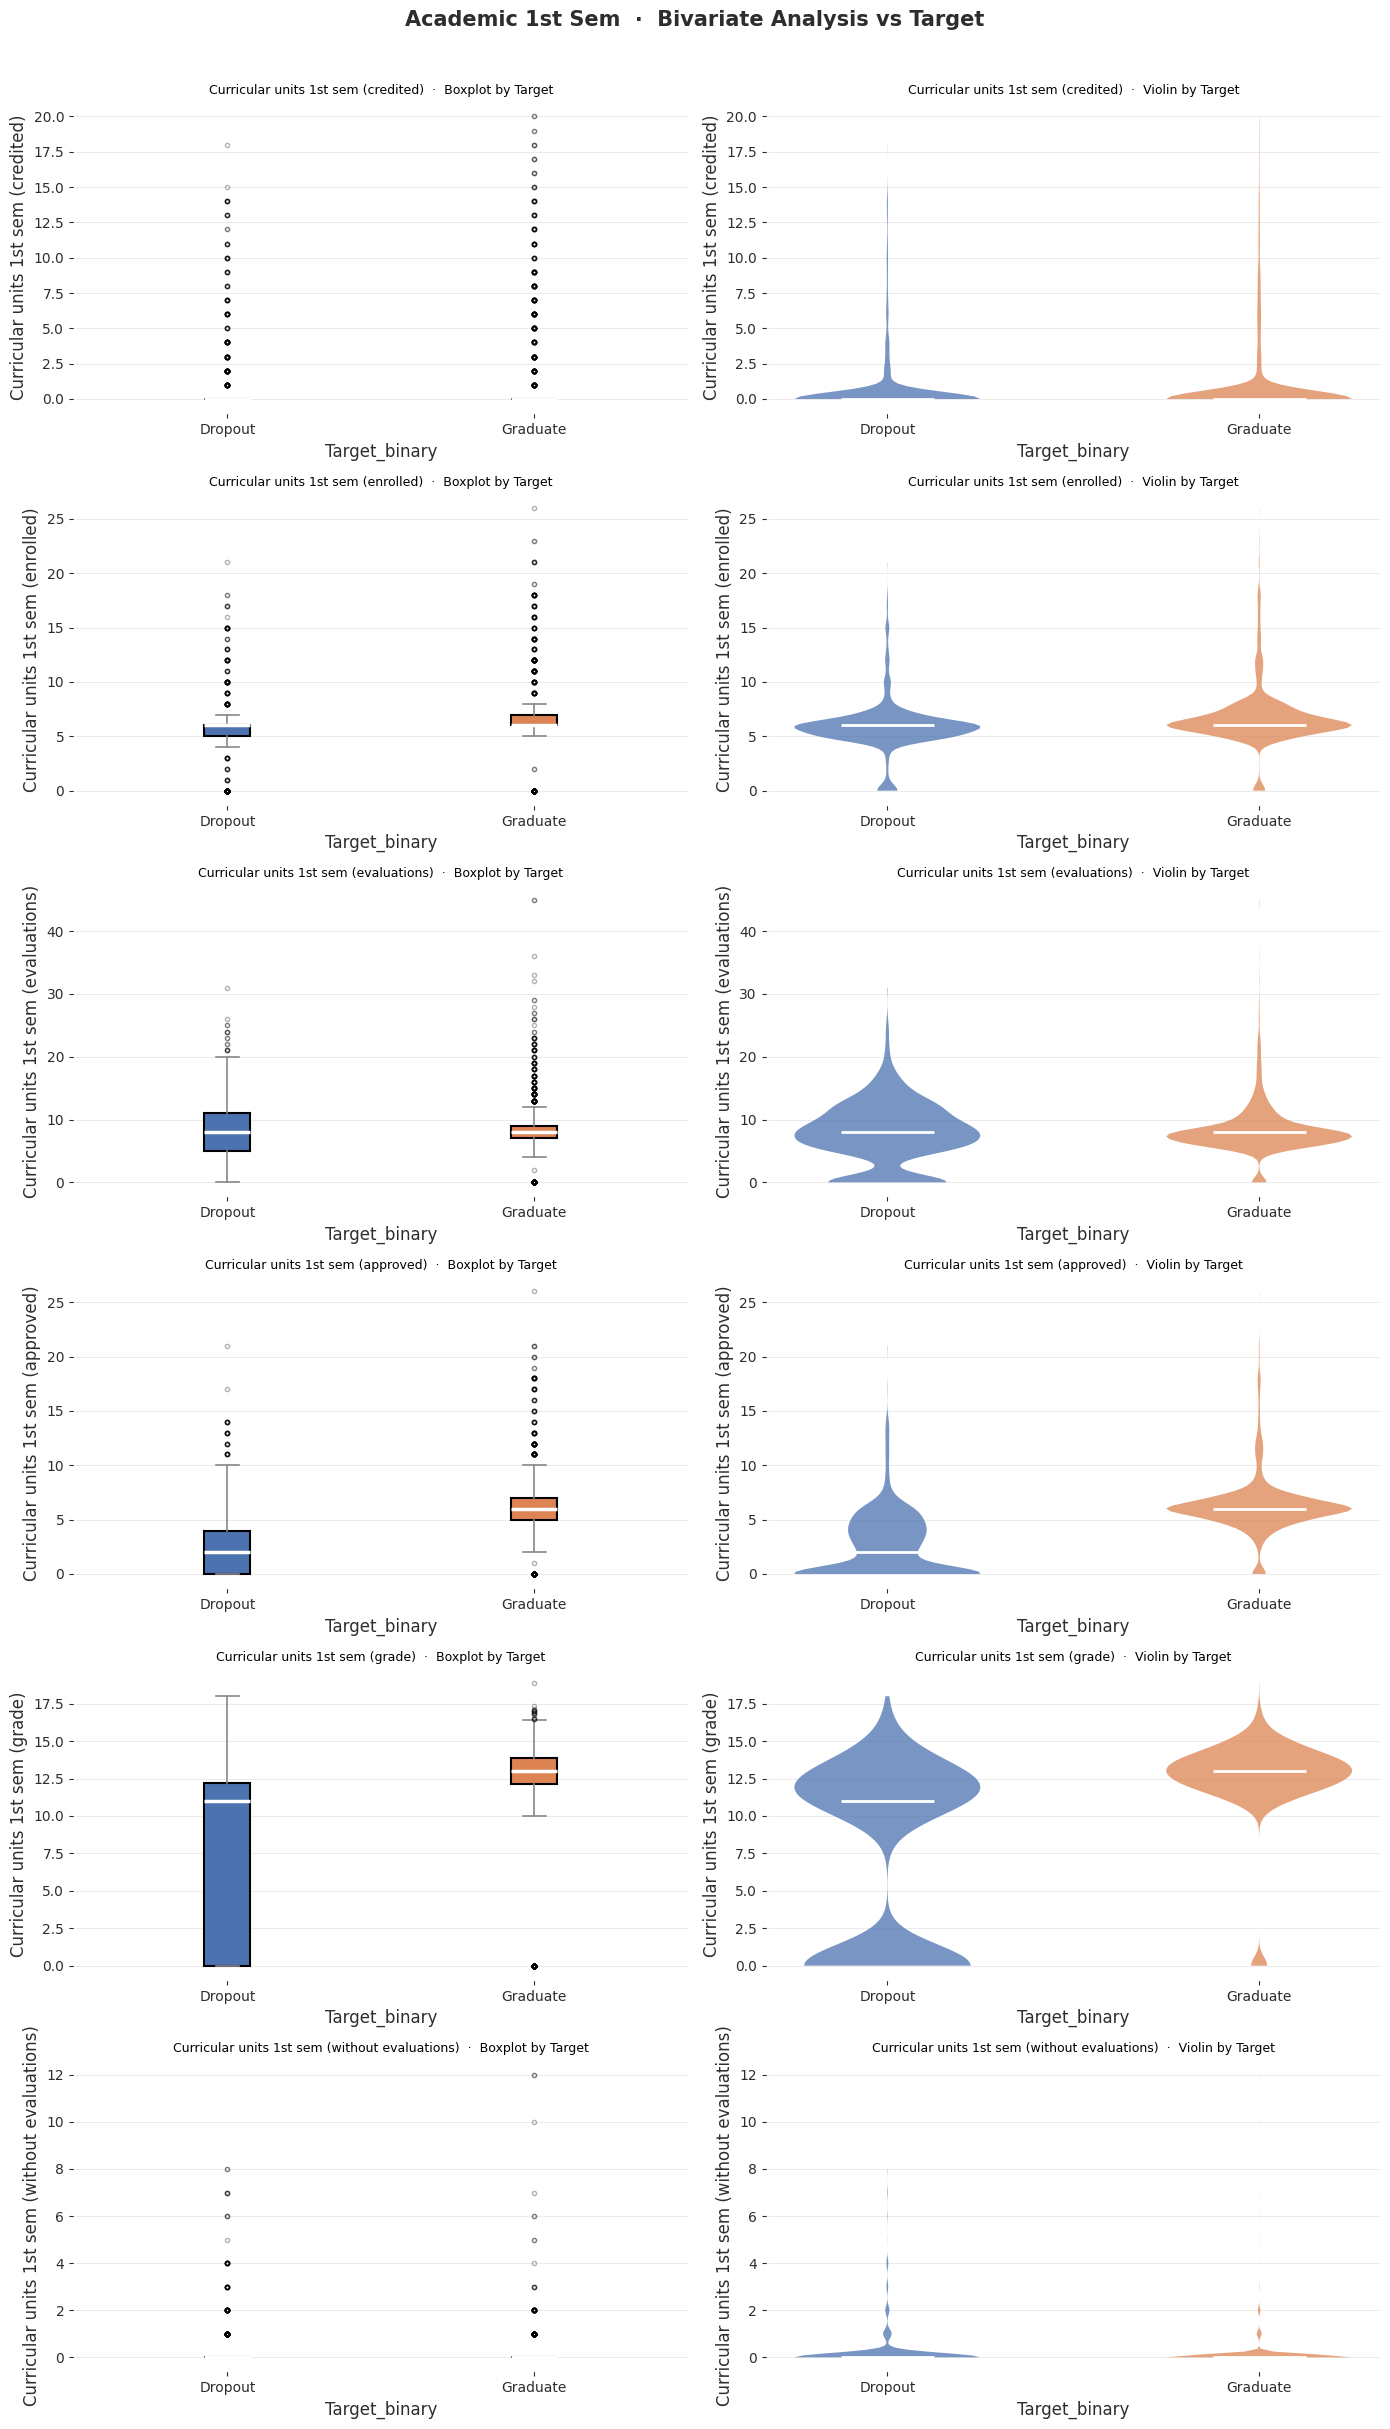

In [174]:
plot_group_with_target(df, academic_1st_sem, group_name="Academic 1st Sem")

***Descriptive Analysis***

**Curricular units credited** shows virtually no separation between dropouts and graduates: both groups are overwhelmingly zero, with sparse outliers across the full range. Prior credits carry no discriminative signal against the target.

**Curricular units enrolled** shows modest separation. Dropouts centre around 5 units while graduates centre slightly higher around 6, with graduates displaying a tighter, more concentrated distribution. The difference is present but small.

**Curricular units evaluations** shows similar overlap, though dropout students display a heavier zero tail — students who sat no evaluations skew heavily toward dropout, visible in both the boxplot and violin.

**Curricular units approved** is the sharpest separator in the group. Dropout students cluster near zero, while graduates concentrate around 5–6 approved units. The violin plots make the contrast stark: dropouts show a dominant zero mass, graduates show a clean unimodal distribution centred on passing most enrolled units.

**Curricular units grade** shows clear separation in direction but with a structural complication. Graduates concentrate tightly between 12–14, while dropouts show a bimodal pattern — a zero cluster (students with no approved units, hence no grade) and a secondary mode around 11–12. The zero mass in the dropout violin is not a true grade and must be handled separately.

**Curricular units without evaluations** shows no meaningful separation — both groups are near-constant at zero, confirming the variable adds no predictive value.

***Key Insights***

**Approved units is the single strongest academic predictor of dropout** — the separation between a near-zero distribution for dropouts and a concentrated passing distribution for graduates is unambiguous. **Grade** reinforces this but requires careful handling of structural zeros before use in modelling. **Enrolled** and **evaluations** add marginal signal. **Credited** and **without evaluations** show no discriminative power and should be dropped or binarised.

### 4.6 Macroeconomic Context vs Target

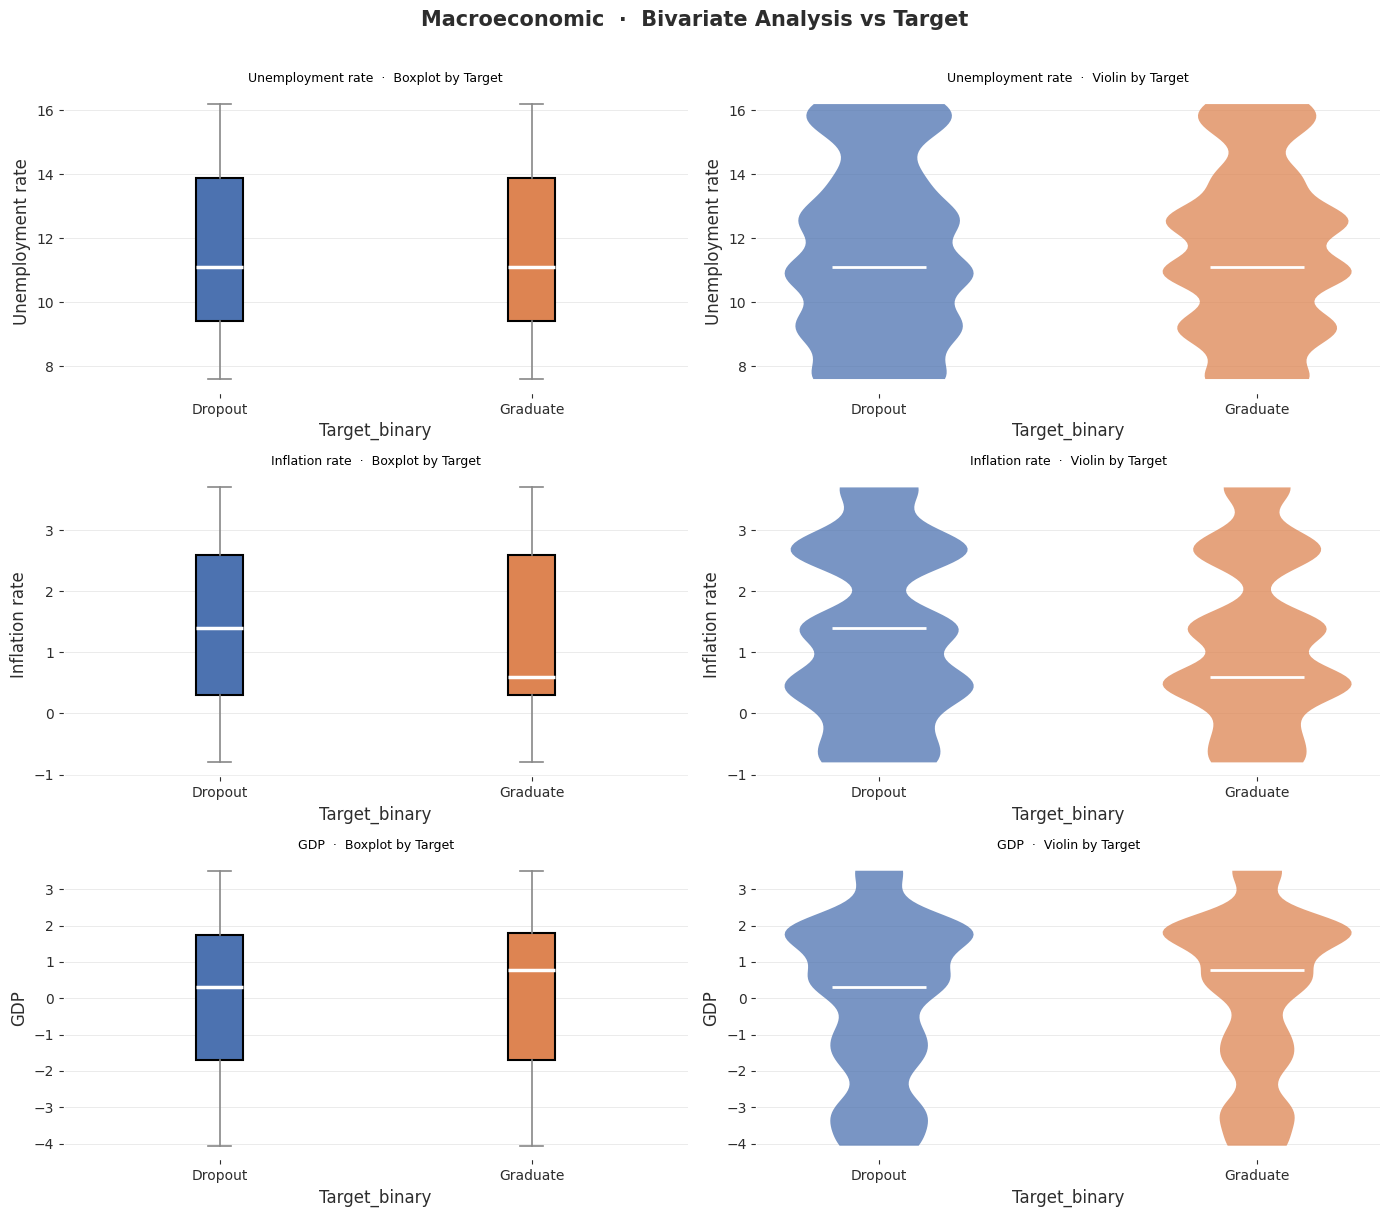

In [175]:
plot_group_with_target(df, macroeconomic,   group_name="Macroeconomic")

***Descriptive Analysis***

**Unemployment rate** shows virtually no separation between dropouts and graduates. Both groups share near-identical medians (~11), interquartile ranges, and violin shapes. The distributions are indistinguishable.

**Inflation rate** mirrors the same pattern. Boxplots and violins overlap almost perfectly across both groups, with identical medians around 1.2–1.3 and matching spread. The multi-modal violin shape, reflecting the discrete time-period structure of the variable, appears symmetrically in both groups.

**GDP** similarly shows no separation. Both dropouts and graduates centre near zero, with equivalent spread across negative and positive growth phases. The violin shapes are near-identical.

***Key Insights***

**Macroeconomic variables carry no discriminative signal against the dropout target.** The complete distributional overlap across all three variables confirms that unemployment rate, inflation, and GDP growth do not differ between students who drop out and those who graduate. This is analytically expected: macroeconomic conditions are shared by all students enrolled in the same period and therefore cannot explain individual-level dropout decisions. **All three variables should be removed from the predictive model.** Their only plausible retained use would be as interaction terms with financial distress indicators, so a student in debt during a high-unemployment period may face compounded risk, but this would require explicit feature engineering to test.

---

## 5. Multivariate Analysis

In the multivariate analysis we examine redundancy and multicollinearity across the key variable groups and then testing two priority interactions against the target, such as financial distress and demographic risk.In order to validate the variable selection decisions made in the univariate and bivariate phases.

### 5.1  Multicollinearity & Redundancy

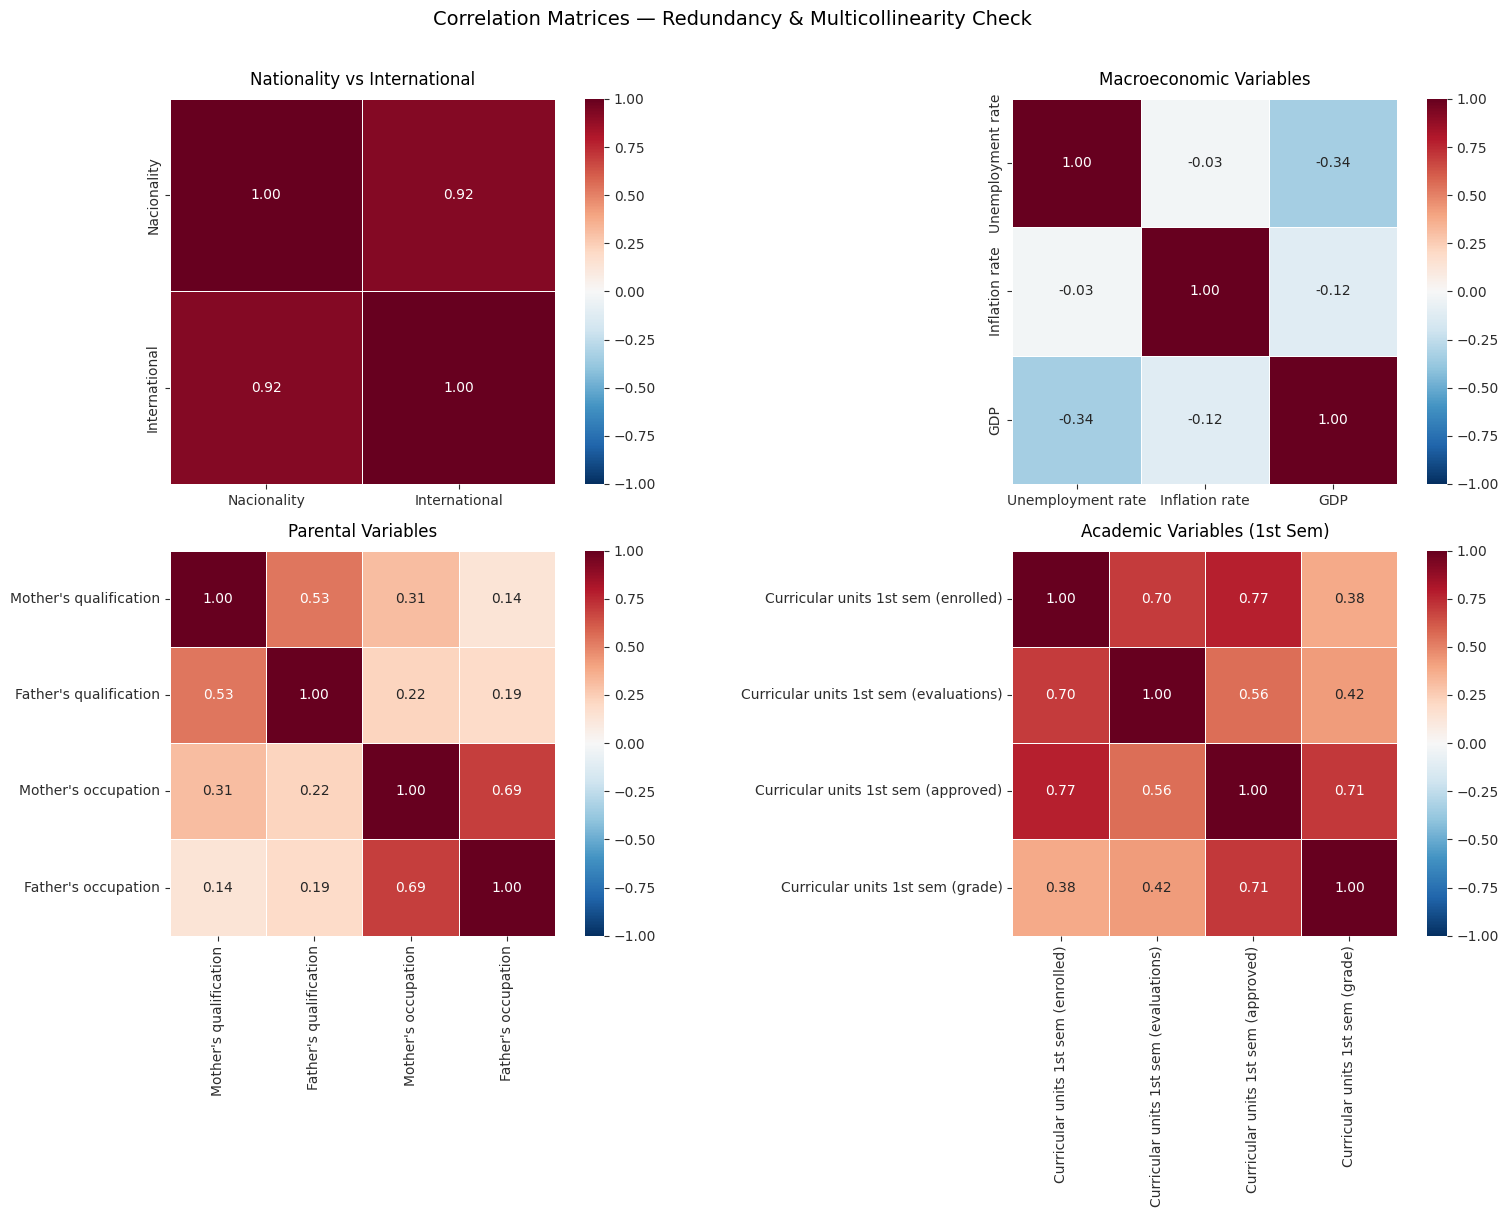

In [176]:
# Nationality vs International 
nat_int_corr = df[['Nacionality', 'International']].corr()

# Macroeconomic variables 
macro_cols = ['Unemployment rate', 'Inflation rate', 'GDP']
macro_corr = df[macro_cols].corr()

# Parental variables 
parental_cols = [
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]
parental_corr = df[parental_cols].corr()

# Academic variables
academic_cols = [
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)'
]
academic_corr = df[academic_cols].corr()

# Plot all four as heatmaps 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, corr, title in zip(
    axes.flatten(),
    [nat_int_corr, macro_corr, parental_corr, academic_corr],
    [
        'Nationality vs International',
        'Macroeconomic Variables',
        'Parental Variables',
        'Academic Variables (1st Sem)'
    ]
):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        square=True,
        ax=ax
    )
    ax.set_title(title, fontsize=12, pad=10)

plt.suptitle('Correlation Matrices — Redundancy & Multicollinearity Check',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

***Descriptive Analysis***

**Nationality vs International** — correlation of 0.92, confirming near-perfect redundancy. Retaining both variables would introduce duplicate information into the model. As both are also near-constant, dropping both is the correct action.

**Macroeconomic variables** — correlations are weak and inconsistent: Unemployment vs Inflation at -0.03, Unemployment vs GDP at -0.34, Inflation vs GDP at -0.12. Contrary to the multicollinearity concern raised in the univariate analysis, these three variables are not strongly correlated with each other. However, since all three showed zero discriminative power against the target in the bivariate analysis, the case for removal stands — on signal grounds, not collinearity grounds.

**Parental variables** — Mother's and Father's qualification correlate at 0.53, and Mother's and Father's occupation at 0.69. Cross-domain correlations (qualification vs occupation) are weaker: 0.31 and 0.19. The occupation pair carries the highest redundancy risk. All four variables retain independent signal and should be kept, but the occupation pair warrants VIF monitoring after encoding.

**Academic variables** — Enrolled vs Approved at 0.77 and Approved vs Grade at 0.71 are the strongest pairs. Enrolled vs Evaluations at 0.70 is also notable. These correlations are expected and do not justify removal, but confirm that an enrolled-to-approved ratio would compress redundant variance into a single, more informative feature in the engineering phase.

***Key Insights***

| Variable Pair | Observed Correlation | Recommendation |
|---------------|---------------------|----------------|
| Nationality ↔ International | 0.92 | Drop both — near-perfect redundancy and near-constant |
| Unemployment ↔ Inflation | -0.03 | Drop both — no collinearity but zero target signal |
| Unemployment ↔ GDP | -0.34 | Drop all three — removal justified on signal grounds only |
| Inflation ↔ GDP | -0.12 | Drop — no target signal |
| Mother's qualification ↔ Father's qualification | 0.53 | Keep both — monitor VIF after encoding |
| Mother's occupation ↔ Father's occupation | 0.69 | Keep both — highest redundancy risk, monitor VIF |
| Curricular units approved ↔ Grade | 0.71 | Keep both — handle via ratio engineering |
| Curricular units enrolled ↔ Approved | 0.77 | Keep both — handle via ratio engineering |
| Curricular units enrolled ↔ Evaluations | 0.70 | Keep both — expected structural correlation |

### 5.2 Key Interactions vs Target

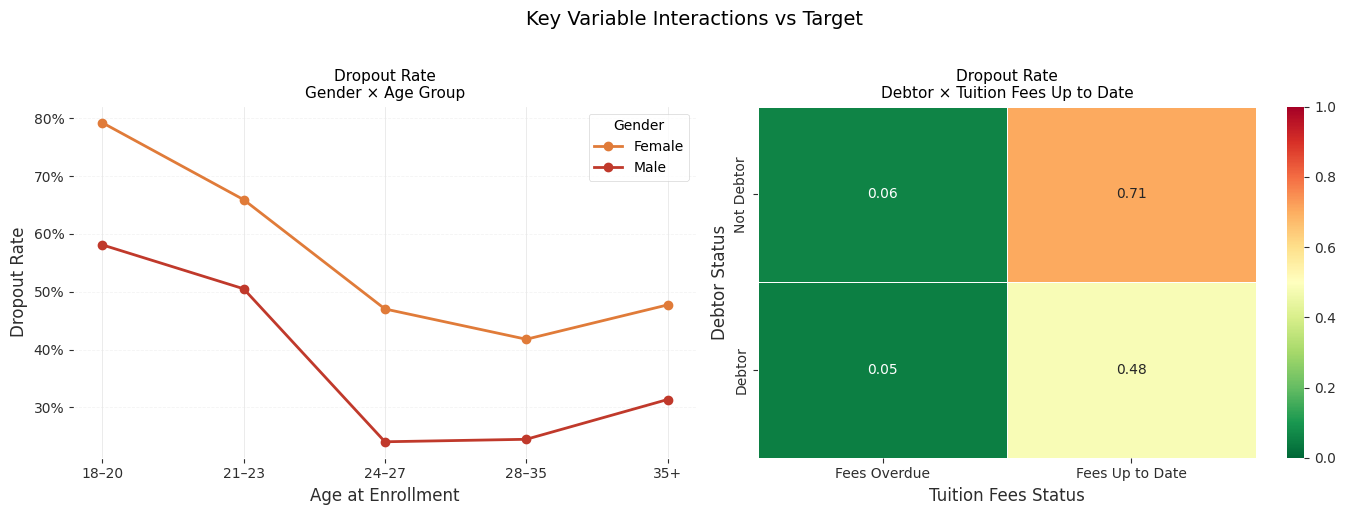

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interaction 1: Gender × Age bins → Dropout rate 
df['Age_bin'] = pd.cut(
    df['Age at enrollment'],
    bins=[17, 20, 23, 27, 35, 70],
    labels=['18–20', '21–23', '24–27', '28–35', '35+']
)

dropout_by_age_gender = (
    df.groupby(['Age_bin', 'Gender'])['Target_binary']
    .agg(lambda x: (x == 0).mean())
    .reset_index()
)
dropout_by_age_gender['Gender'] = dropout_by_age_gender['Gender'].map({0: 'Female', 1: 'Male'})

for gender, color in [('Female', '#e07b39'), ('Male', '#c0392b')]:
    sub = dropout_by_age_gender[dropout_by_age_gender['Gender'] == gender]
    axes[0].plot(sub['Age_bin'], sub['Target_binary'],
                 marker='o', label=gender, color=color, linewidth=2)
axes[0].set_title('Dropout Rate\nGender × Age Group', fontsize=11)
axes[0].set_xlabel('Age at Enrollment')
axes[0].set_ylabel('Dropout Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[0].legend(title='Gender')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Interaction 2: Debtor × Tuition fees → Dropout rate heatmap
pivot2 = (
    df.groupby(['Debtor', 'Tuition fees up to date'])['Target_binary']
    .agg(lambda x: (x == 0).mean())
    .unstack()
)
pivot2.index = ['Not Debtor', 'Debtor']
pivot2.columns = ['Fees Overdue', 'Fees Up to Date']

sns.heatmap(
    pivot2, annot=True, fmt='.2f',
    cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Dropout Rate\nDebtor × Tuition Fees Up to Date', fontsize=11)
axes[1].set_xlabel('Tuition Fees Status')
axes[1].set_ylabel('Debtor Status')

plt.suptitle('Key Variable Interactions vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

***Descriptive Analysis***

**Gender × Age at Enrollment** — the gender gap holds consistently across all age groups at roughly 20–25 points, with males always higher. Both groups reach their minimum dropout rate at 24–27 before rising again from 28+ onward, suggesting mature age compounds risk independently of gender.

**Debtor × Tuition Fees Up to Date** — current payment status dominates. Non-debtors with fees up to date sit at just 6% dropout. Fees overdue alone pushes this to 71%, regardless of debt history. Historical debt alone (fees current) sits at 48%, serious but clearly secondary to current payment failure.

***Key Insights***

**Tuition fees up to date is the single most decisive variable in the dataset** a 6% to 71% dropout gap from one binary flag leaves no ambiguity. **Gender and age act as independent additive risk factors** rather than interacting: the gap is stable, not amplifying. Both interactions confirm the variable selection and engineering decisions made in the earlier analysis.

---

## 6. Key Findings & Takeaways

| Variable | Status | Justification |
|----------|--------|---------------|
| Tuition fees up to date | ✅ Keep | Near-perfect separation (94.4% dropout when overdue) |
| Curricular units approved (1st sem) | ✅ Keep | Strongest continuous academic separator |
| Debtor | ✅ Keep | 75.4% dropout rate, complements tuition fees |
| Scholarship holder | ✅ Keep | Cuts dropout to 13.9%, strong protective signal |
| Curricular units grade (1st sem) | ✅ Keep | Clear separation after structural zeros handled |
| Gender | ✅ Keep | 26-point dropout gap, balanced split |
| Age at enrollment | ✅ Keep | Strong signal, transformation required |
| Course | ✅ Keep | Discipline-level variation confirmed |
| Application mode | ✅ Keep | Mature/non-standard entry doubles dropout rate |
| Daytime/evening attendance | ✅ Keep | Evening students exceed 50% dropout threshold |
| Mother's occupation | ✅ Keep | Unskilled workers at 70.9% vs 29.2% professionals |
| Father's qualification | ✅ Keep | Consistent gradient from basic to higher education |
| Mother's qualification | ✅ Keep | Mirrors father qualification signal |
| Father's occupation | ✅ Keep | Mirrors mother occupation signal |
| Curricular units enrolled (1st sem) | ✅ Keep | Modest signal; retained as ratio denominator |
| Curricular units evaluations (1st sem) | ✅ Keep | Zero spike flags disengagement; high evaluations-to-enrolled ratio flags repeated exam failure: both ends of the distribution carry dropout signal |
| Marital status | ⚠️ Weak / Moderate | Dominated by singles, small subgroups unreliable |
| Previous qualification | ⚠️ Weak / Moderate | 83.7% Secondary Education, sparse categories |
| Application order | ⚠️ Weak / Moderate | Non-linear gradient, needs further investigation |
| Nationality | ❌ Drop | Near-constant, negligible signal |
| International | ❌ Drop | Near-constant, redundant with Nationality |
| Educational special needs | ❌ Drop | 40 positive cases, no discriminative power |
| Curricular units credited (1st sem) | ❌ Drop | Zero-inflated, no bivariate separation |
| Curricular units without evaluations (1st sem) | ❌ Drop | Near-constant at zero, no signal |
| Unemployment rate | ❌ Drop | Identical distributions across dropout/graduate |
| Inflation rate | ❌ Drop | Identical distributions across dropout/graduate |
| GDP | ❌ Drop | Identical distributions across dropout/graduate |
| Displaced | ❌ Drop | No marginal signal confirmed in bivariate analysis |